In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

from algorithms import *
from envs import *
from helpers import *

### Helper fucntions and classes

### Checking everything with a small example

#### IID Gaussian

In [5]:
n_states = 5
max_time = 10
max_stops = 2
Q_init = np.zeros((n_states, max_time + 1, max_stops + 1, 2)) 
holding_cost_per_step = 0.0

for i in range(n_states):
    Q_init[i,1:,1,1] = i

for i in range(n_states):
    Q_init[i,1,2,1] = -i - holding_cost_per_step


n_ep = 50000




buy_sell_simple_env = BuySellEnv(n_states=5, max_time=10, transition_model='iid_geometric', holding_cost_per_step=holding_cost_per_step)
asched = linear_decay_schedule(1.0, 0.01, n_ep)
esched = linear_decay_schedule(1.0, 0.1, n_ep)
agent = QLearningAgent(env=buy_sell_simple_env, alpha_schedule=asched, epsilon_schedule=esched, Q_init=Q_init)


results = agent.train(env=buy_sell_simple_env, n_episodes=n_ep, verbose = 0 , use_tqdm=True)
viz = visualizer(buy_sell_simple_env, agent)

Training:   0%|                                                      | 0/50000 [00:00<?, ?episode/s]

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 2.8352
  Buy (stop 1) accept rate: 24.00%
  Sell (stop 2) accept rate: 46.00%


#### Sanity check - Visited states distribution

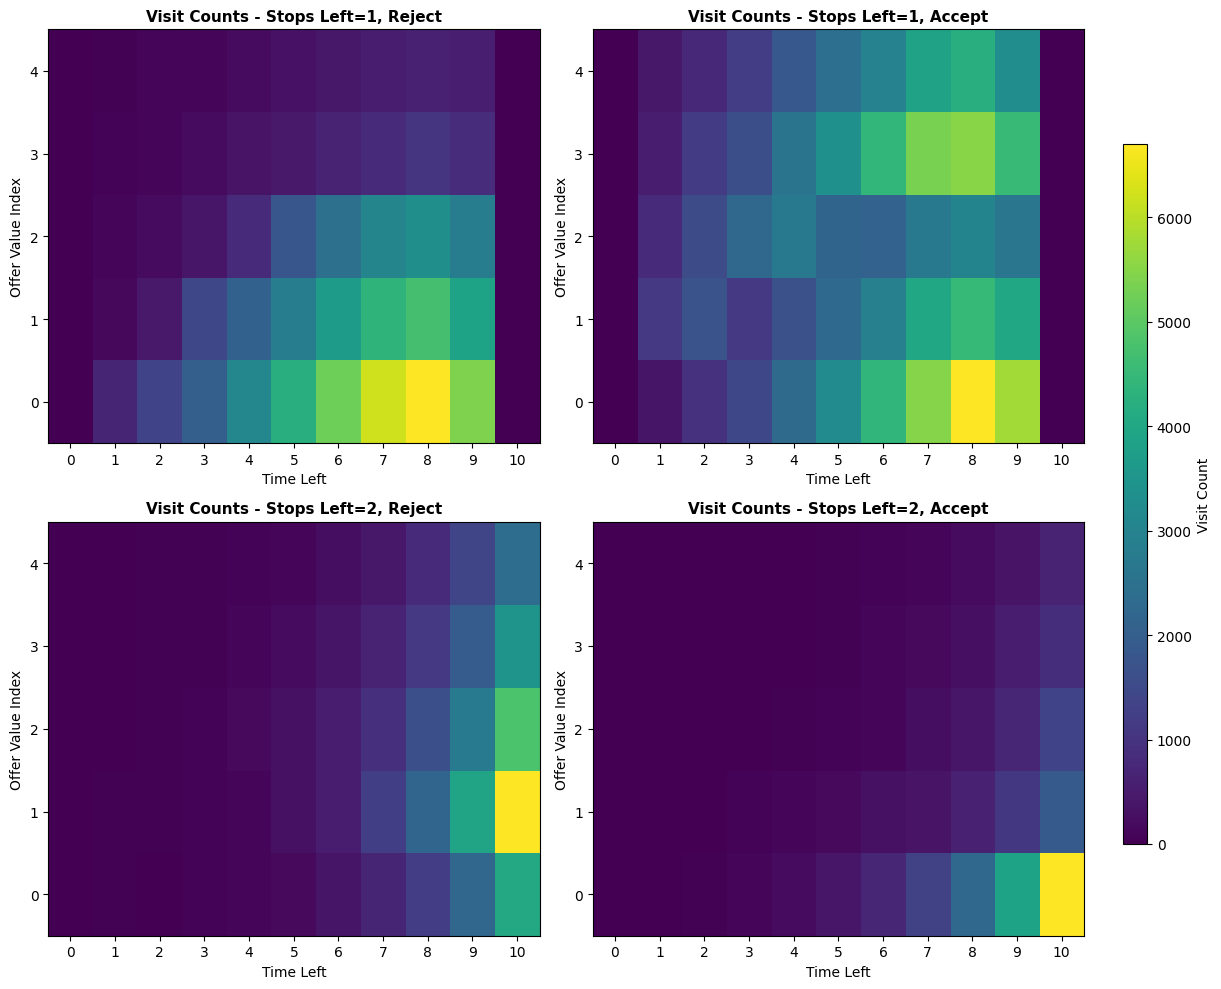

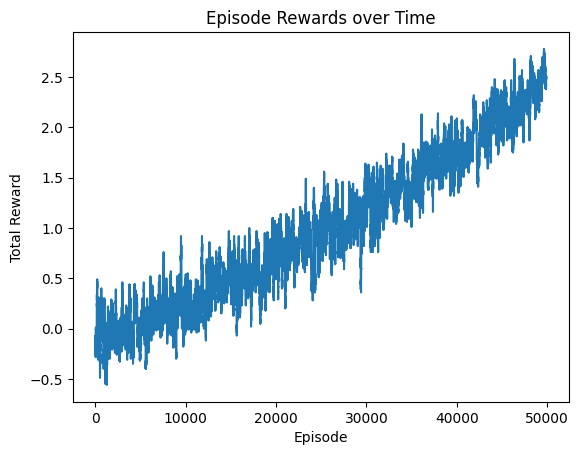

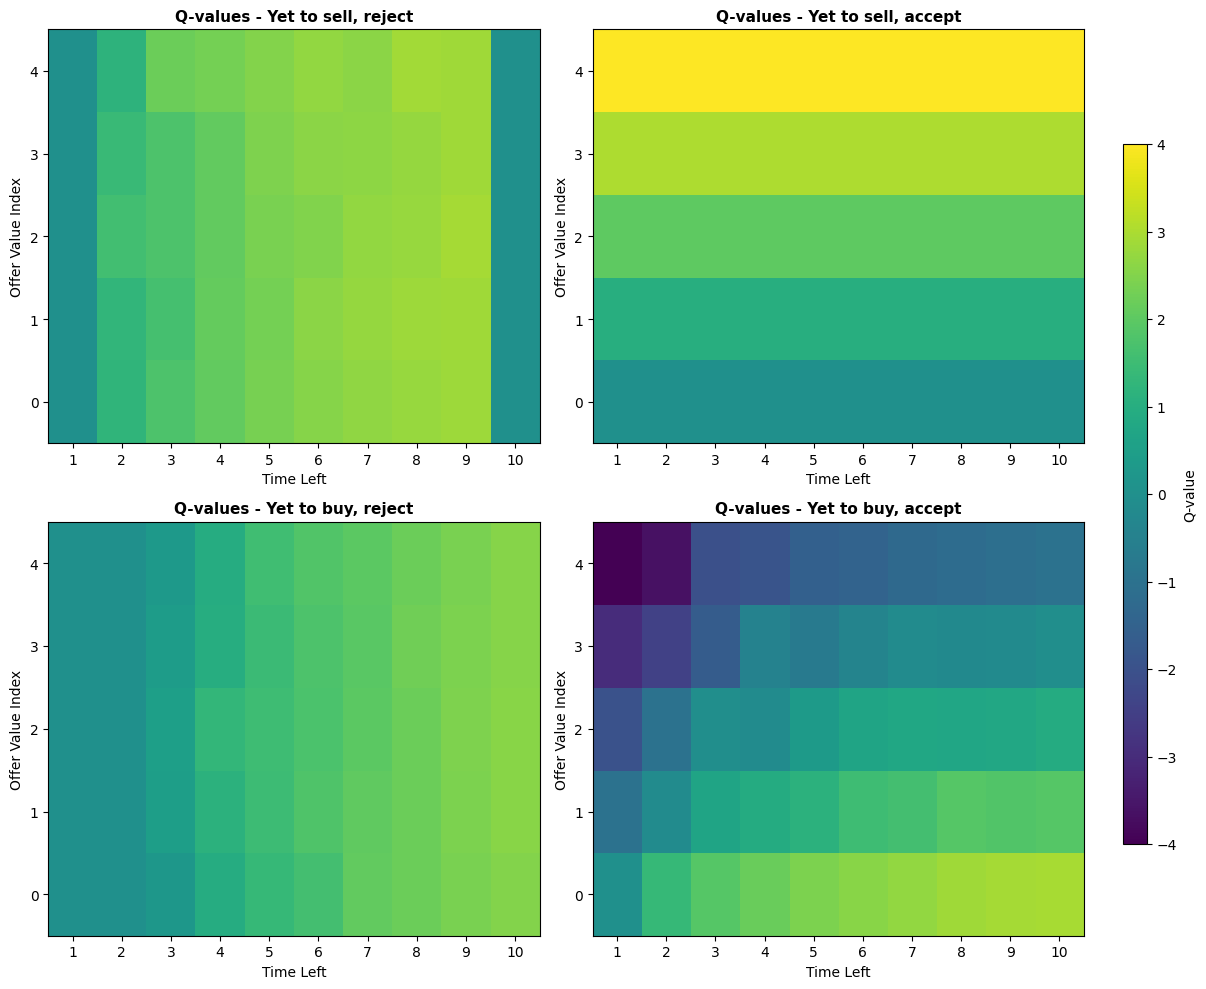

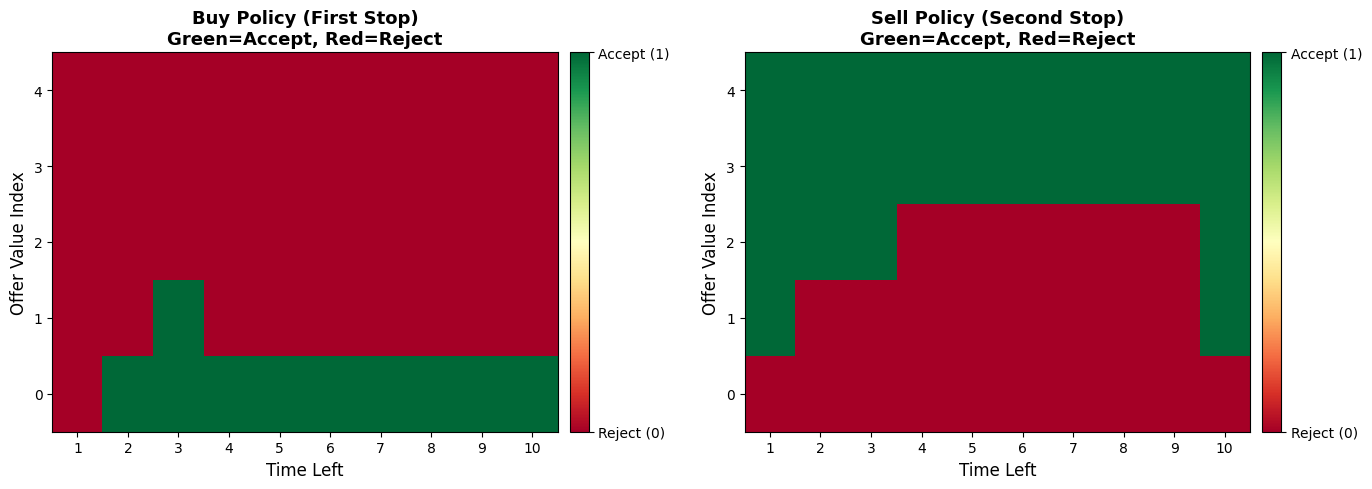


Q-Learning Policy Statistics:
Buy Policy - Accept rate: 20.00%
Sell Policy - Accept rate: 52.00%


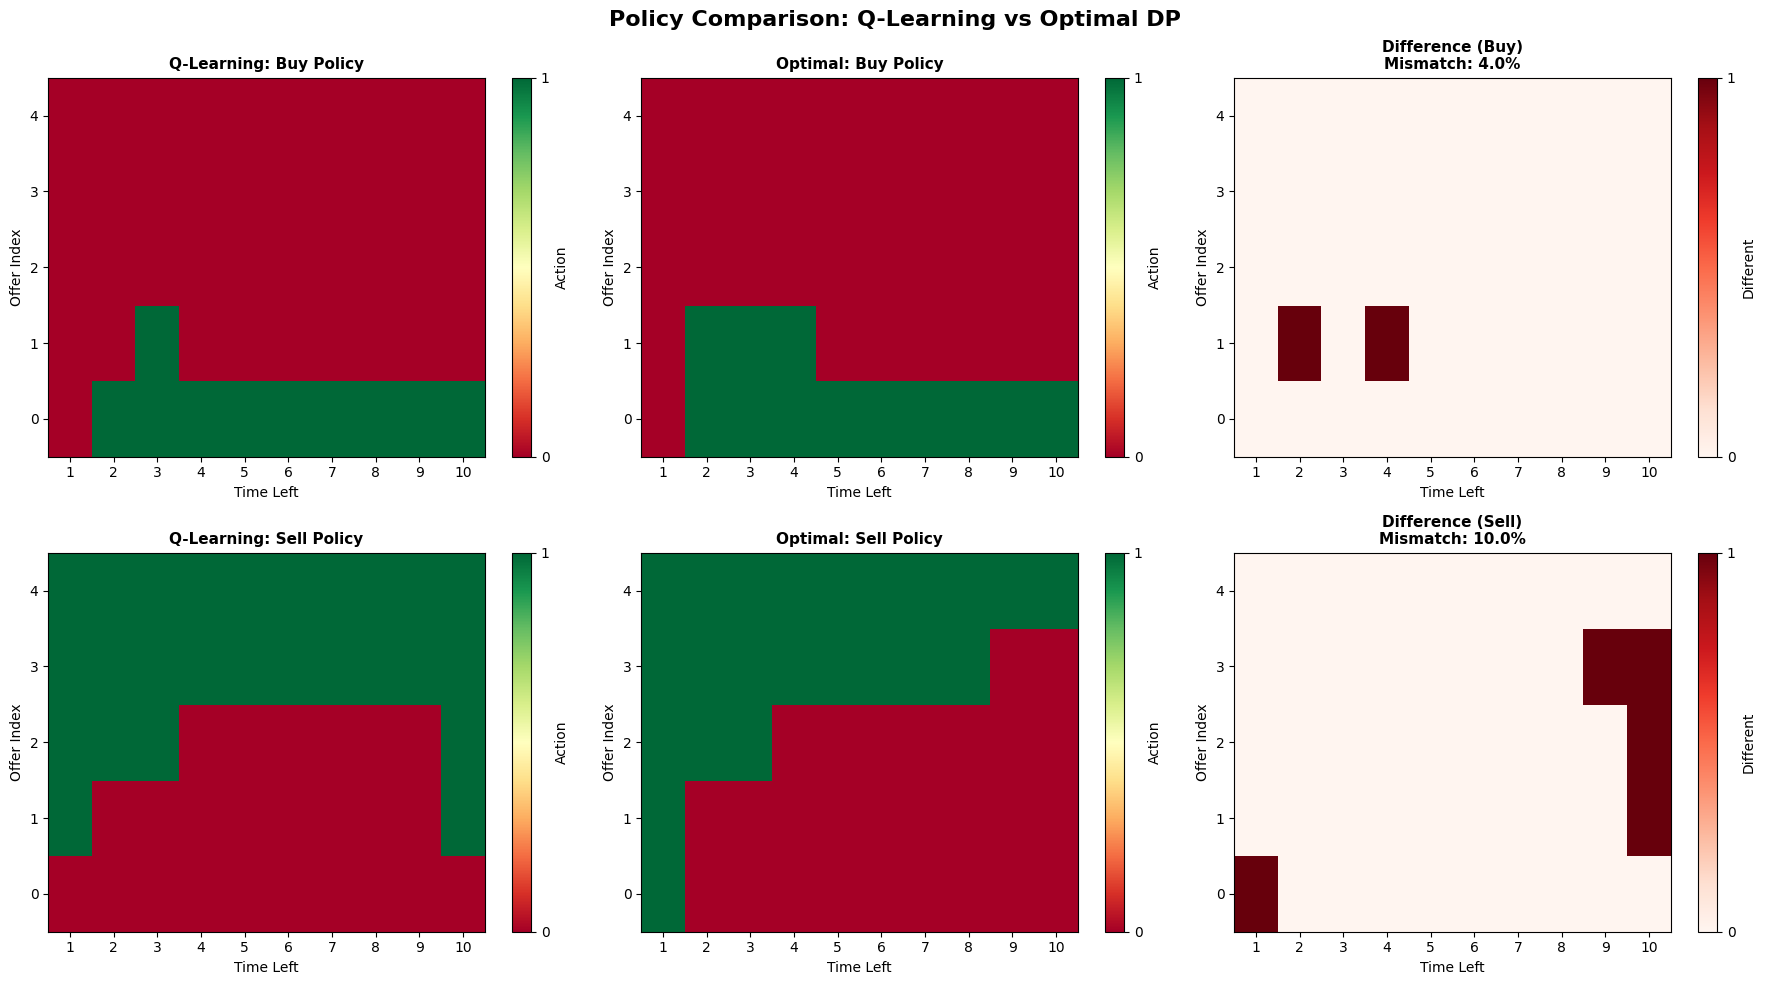


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 20.00%
  Optimal accept rate: 24.00%
  Agreement: 96.00%
  Mismatch: 4.00%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 52.00%
  Optimal accept rate: 46.00%
  Agreement: 90.00%
  Mismatch: 10.00%

Overall Policy Agreement: 93.00%


In [6]:
viz.pipeline(compare_optimal=True)  

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 2.6345
  Buy (stop 1) accept rate: 42.00%
  Sell (stop 2) accept rate: 32.00%


Evaluating Q-Learning: 100%|██████████| 1000000/1000000 [01:14<00:00, 13434.76it/s]



Evaluation Summary: Q-Learning
Episodes: 1000000

Reward Statistics:
  Mean:          2.3799
  Std:           1.0602
  Sharpe:        2.2448
  Median:        3.0000
  Min:          -2.0000
  Max:           4.0000

Episode Length:
  Mean:            7.01
  Std:             2.17

Buy-Sell Specific Metrics:
  Completion rate:   96.81%
  Mean buy price:      0.9870
  Mean sell price:     3.4512
  Mean profit:         2.4652
  Mean holding time:     3.21



Evaluating Optimal DP: 100%|██████████| 1000000/1000000 [01:17<00:00, 12915.66it/s]



Evaluation Summary: Optimal DP
Episodes: 1000000

Reward Statistics:
  Mean:          2.3993
  Std:           1.1305
  Sharpe:        2.1224
  Median:        3.0000
  Min:          -2.0000
  Max:           4.0000

Episode Length:
  Mean:            7.39
  Std:             2.34

Buy-Sell Specific Metrics:
  Completion rate:   97.35%
  Mean buy price:      0.9435
  Mean sell price:     3.4081
  Mean profit:         2.4646
  Mean holding time:     3.44


Policy Comparison: Q-Learning vs Optimal DP

Metric                         Q-Learning      Optimal DP     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        2.3799          2.3993   +0.0194 (+0.8%)   Optimal DP
Std Reward                         1.0602          1.1305   +0.0703 (+6.6%)   Q-Learning
Sharpe Ratio                       2.2448          2.1224   -0.1224 (-5.5%)   Q-Learning
Median Reward                      3.0000          3.0000   +0.0000 (+0.0%

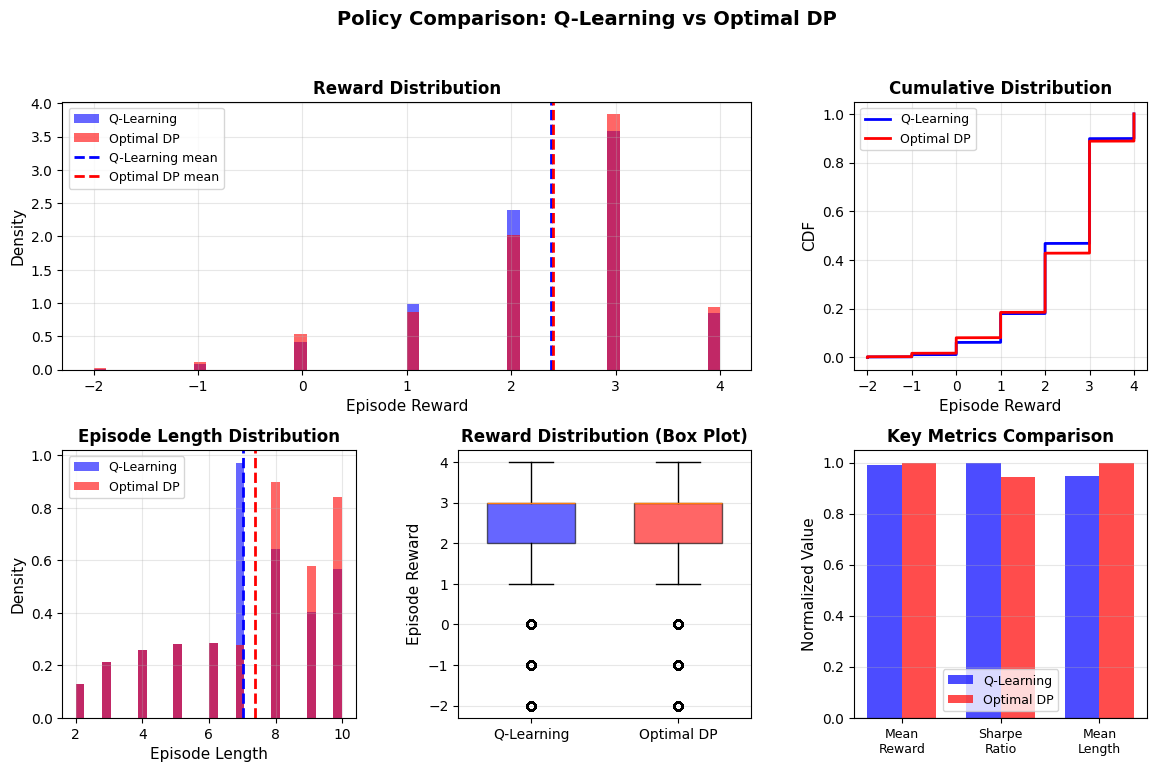

In [11]:
opt_policy = env.solve_optimal_policy()[1]
q_policy = agent.get_policy()
evaluator = PolicyEvaluator(env=buy_sell_simple_env)
# print("Q-Learning Policy Evaluation:")
evaluator.compare_policies(q_policy, opt_policy, n_episodes=1000000, policy1_name="Q-Learning", policy2_name="Optimal DP")
evaluator.plot_comparison()

#### IID Uniform

Training:   0%|                                                     | 0/100000 [00:00<?, ?episode/s]

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 3.1336
  Buy (stop 1) accept rate: 34.00%
  Sell (stop 2) accept rate: 34.00%


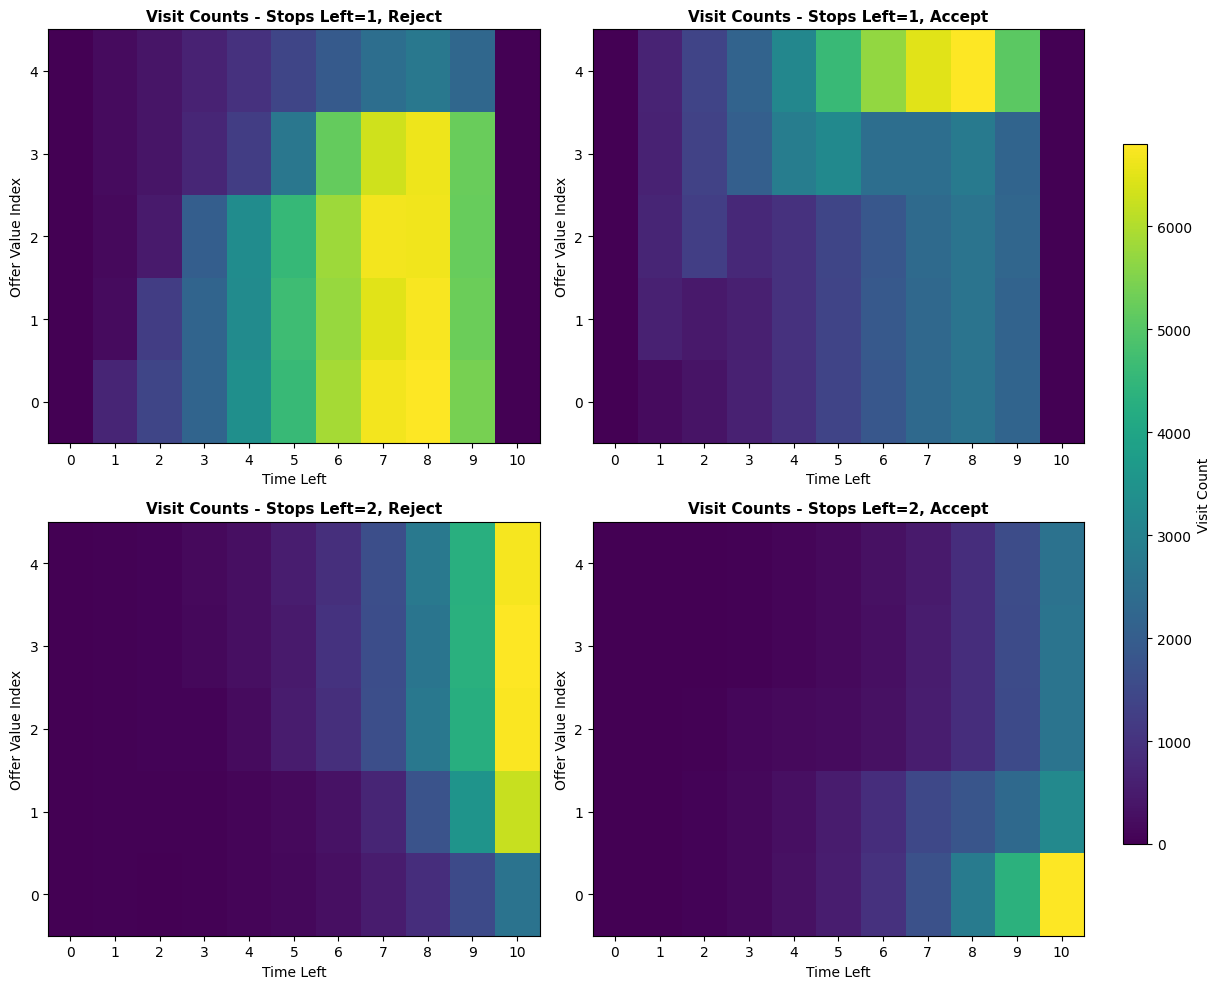

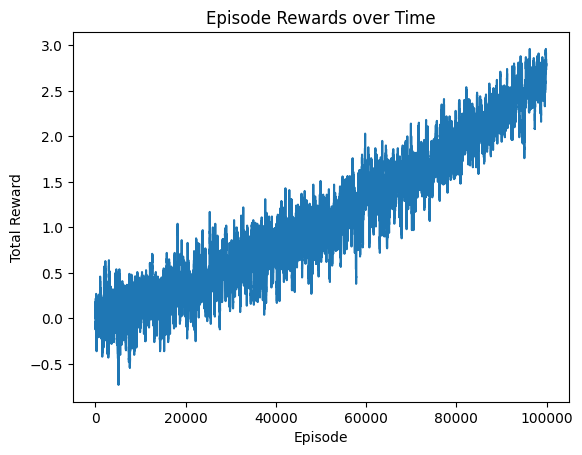

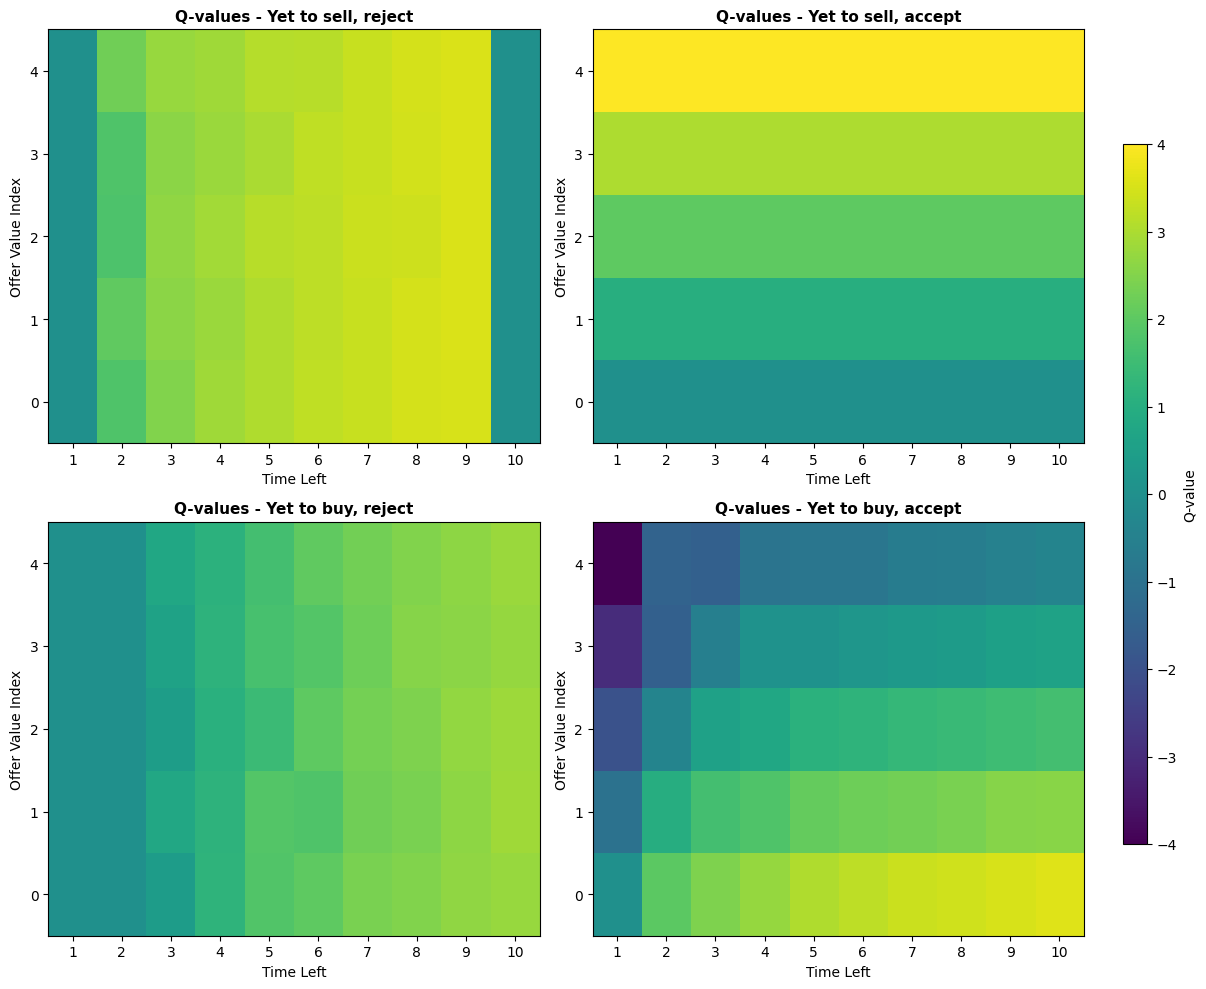

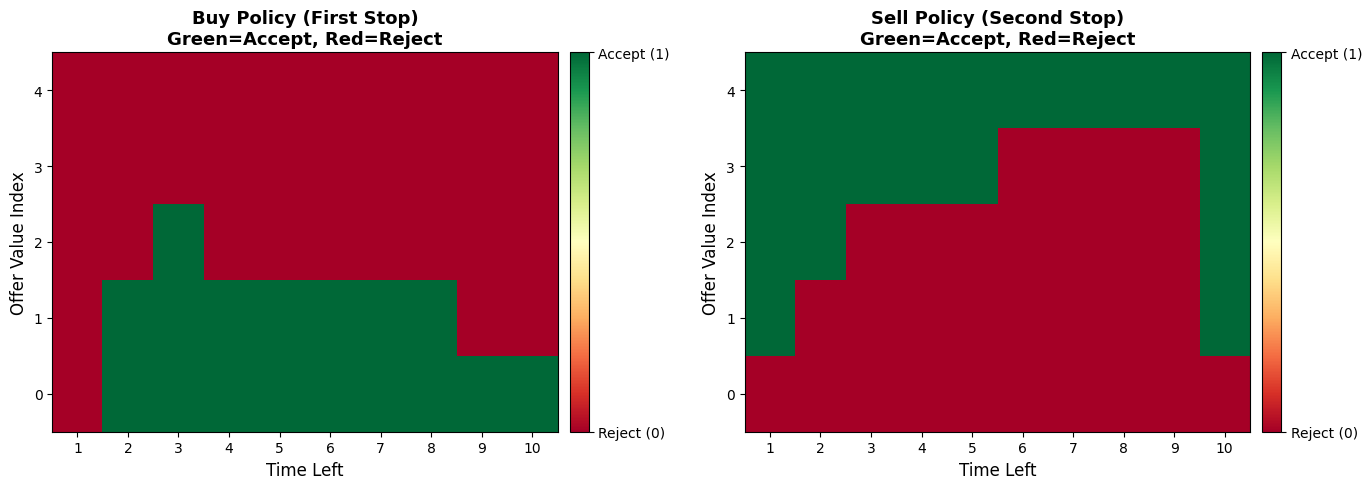


Q-Learning Policy Statistics:
Buy Policy - Accept rate: 34.00%
Sell Policy - Accept rate: 42.00%


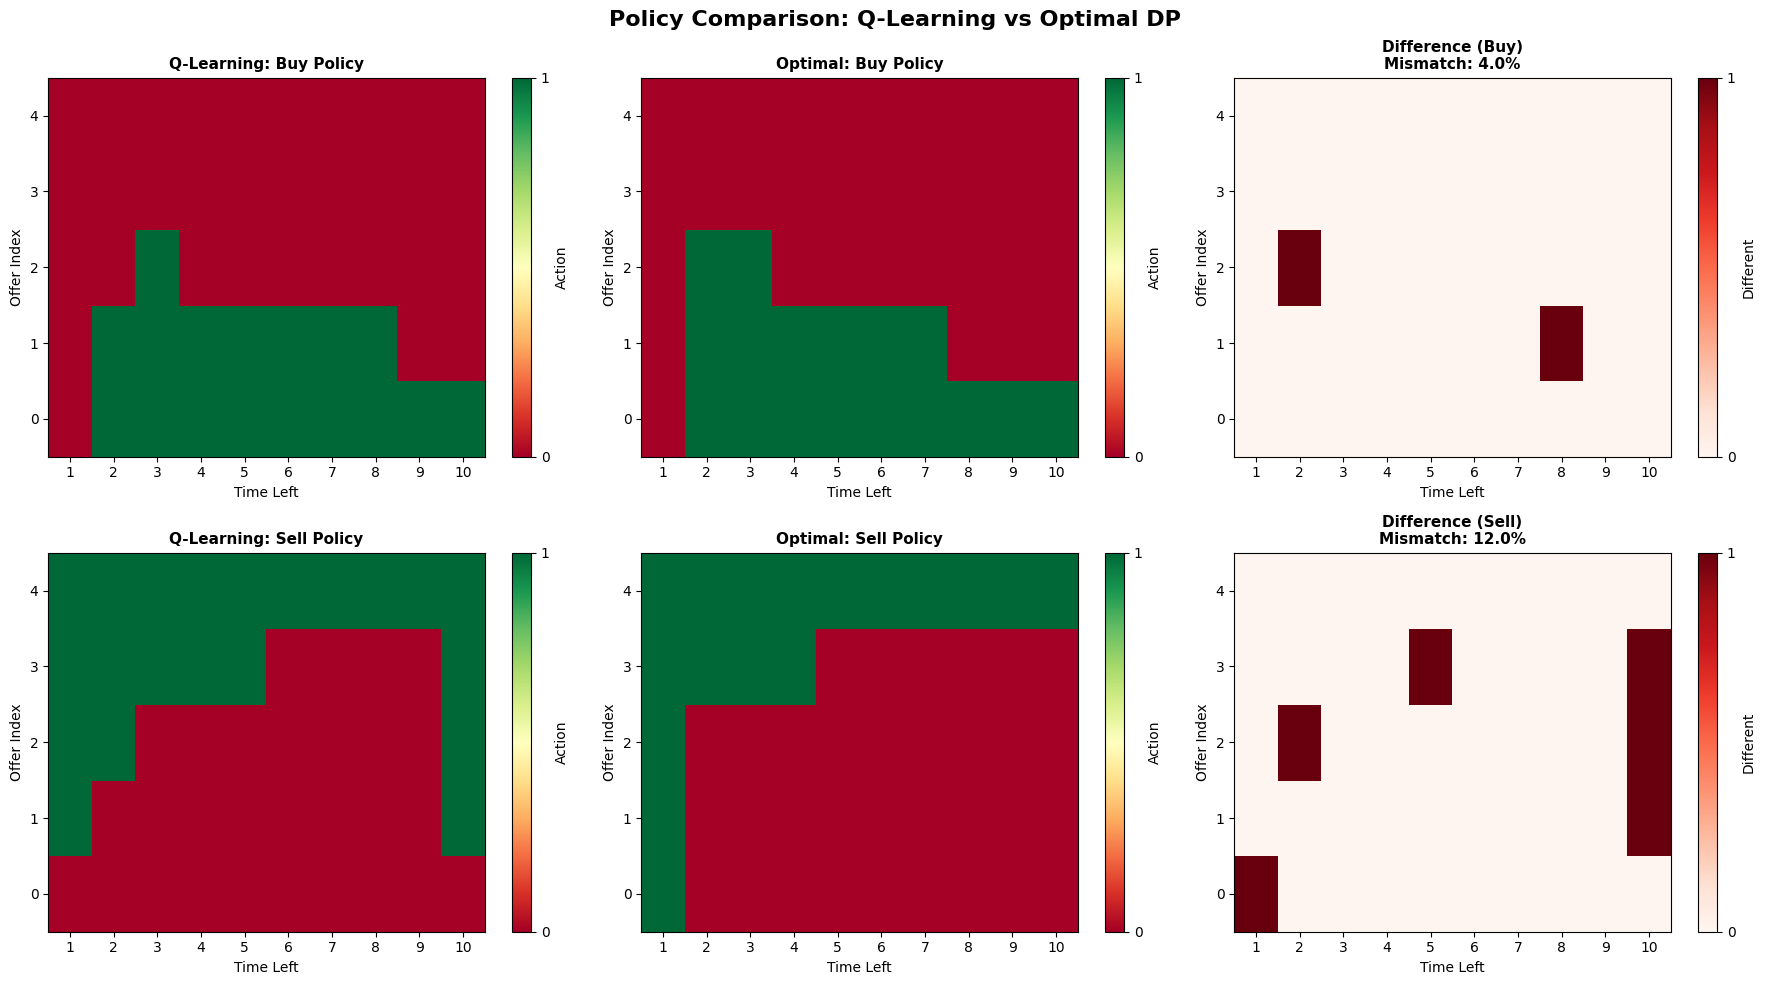


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 34.00%
  Optimal accept rate: 34.00%
  Agreement: 96.00%
  Mismatch: 4.00%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 42.00%
  Optimal accept rate: 34.00%
  Agreement: 88.00%
  Mismatch: 12.00%

Overall Policy Agreement: 92.00%


In [14]:
n_ep = 100000
uniform_env = BuySellEnv(n_states=5, max_time=10, transition_model='iid', holding_cost_per_step=0.0)
uniform_agent = QLearningAgent(env=uniform_env, alpha_schedule=asched, epsilon_schedule=esched, Q_init=Q_init)
uniform_agent.train(env=uniform_env, n_episodes=n_ep, verbose = 0 , use_tqdm=True)
uniform_viz = visualizer(uniform_env, uniform_agent)
uniform_viz.pipeline(compare_optimal=True)

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 3.1336
  Buy (stop 1) accept rate: 34.00%
  Sell (stop 2) accept rate: 34.00%


Evaluating Q-Learning: 100%|██████████| 100000/100000 [00:06<00:00, 14419.89it/s]



Evaluation Summary: Q-Learning
Episodes: 100000

Reward Statistics:
  Mean:          3.1125
  Std:           1.0479
  Sharpe:        2.9703
  Median:        3.0000
  Min:          -2.0000
  Max:           4.0000

Episode Length:
  Mean:            6.41
  Std:             2.16

Buy-Sell Specific Metrics:
  Completion rate:   97.21%
  Mean buy price:      0.3300
  Mean sell price:     3.5374
  Mean profit:         3.2096
  Mean holding time:     3.06



Evaluating Optimal DP: 100%|██████████| 100000/100000 [00:07<00:00, 13544.03it/s]



Evaluation Summary: Optimal DP
Episodes: 100000

Reward Statistics:
  Mean:          3.1321
  Std:           1.1868
  Sharpe:        2.6390
  Median:        4.0000
  Min:          -2.0000
  Max:           4.0000

Episode Length:
  Mean:            6.87
  Std:             2.30

Buy-Sell Specific Metrics:
  Completion rate:   98.95%
  Mean buy price:      0.2826
  Mean sell price:     3.4479
  Mean profit:         3.1653
  Mean holding time:     3.24


Policy Comparison: Q-Learning vs Optimal DP

Metric                         Q-Learning      Optimal DP     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        3.1125          3.1321   +0.0195 (+0.6%)   Optimal DP
Std Reward                         1.0479          1.1868   +0.1390 (+13.3%)   Q-Learning
Sharpe Ratio                       2.9703          2.6390   -0.3313 (-11.2%)   Q-Learning
Median Reward                      3.0000          4.0000   +1.0000 (+33.

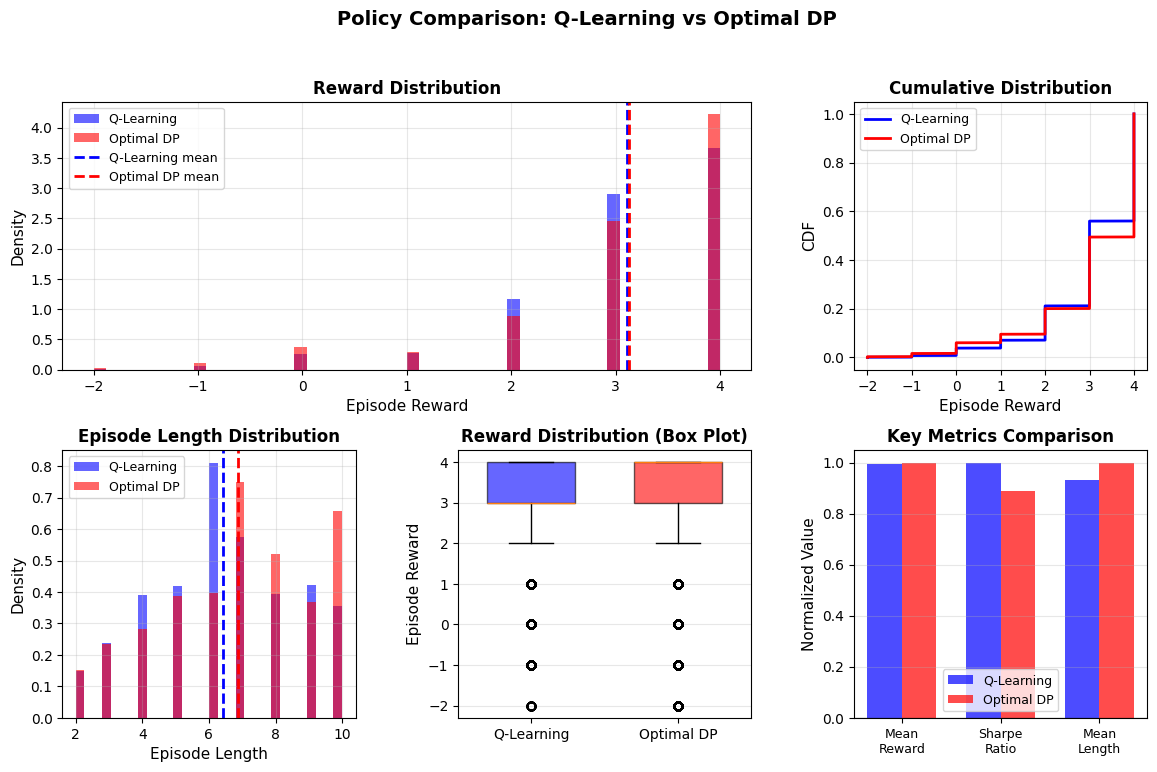

In [15]:
pe = PolicyEvaluator(env=uniform_env)
pe.compare_policies(uniform_agent.get_policy(), uniform_env.solve_optimal_policy()[1], n_episodes=100000, policy1_name="Q-Learning", policy2_name="Optimal DP")
pe.plot_comparison()

### Larger example

Training:   0%|                                                    | 0/5000000 [00:00<?, ?episode/s]

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 7.4551
  Buy (stop 1) accept rate: 34.80%
  Sell (stop 2) accept rate: 43.20%


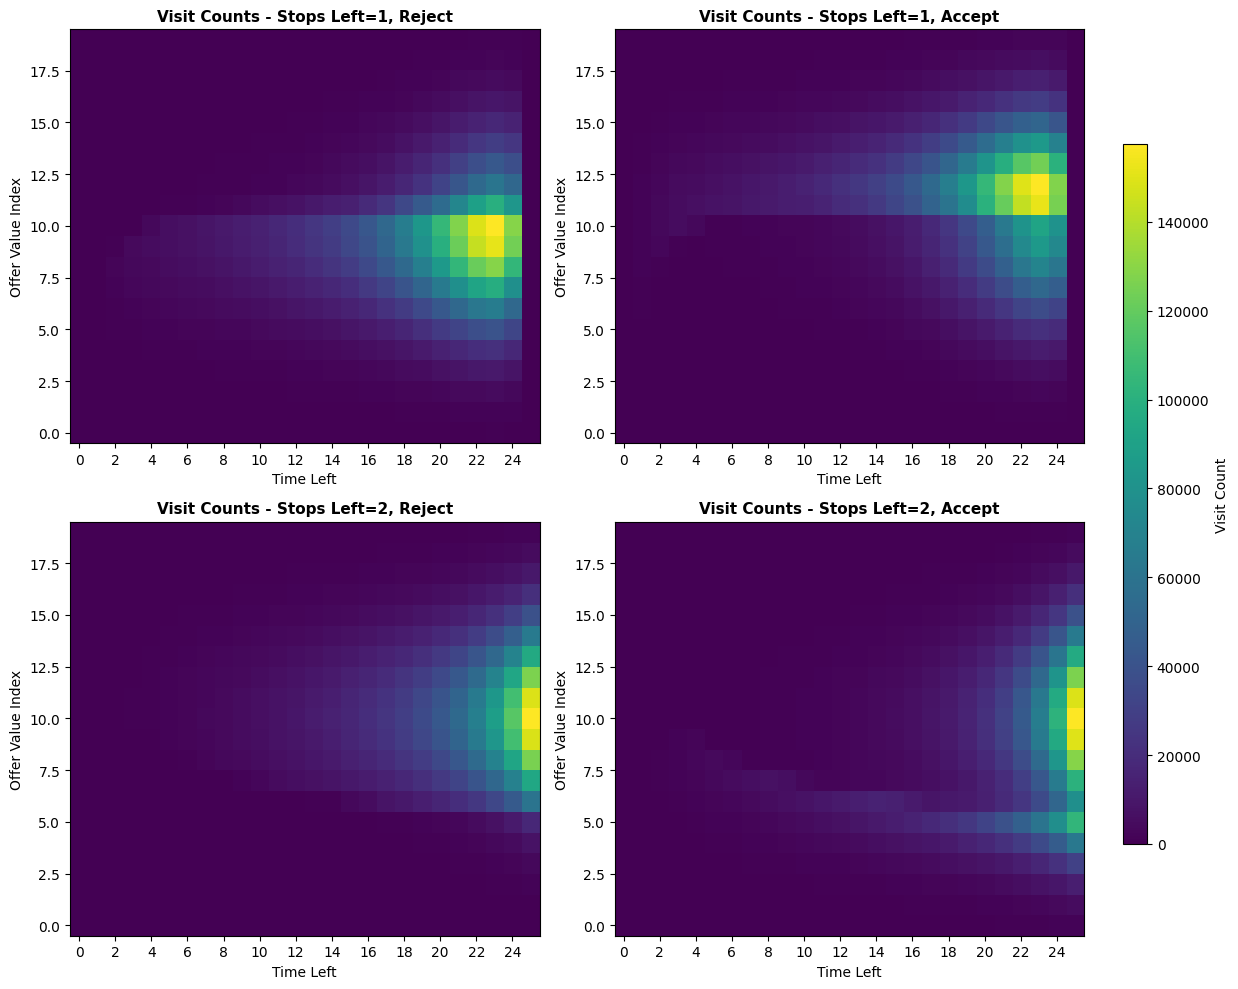

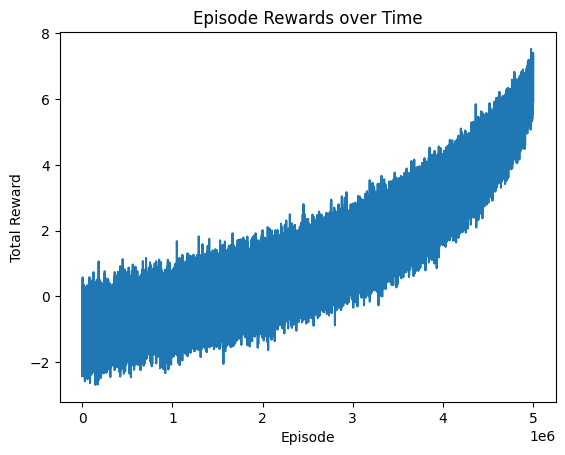

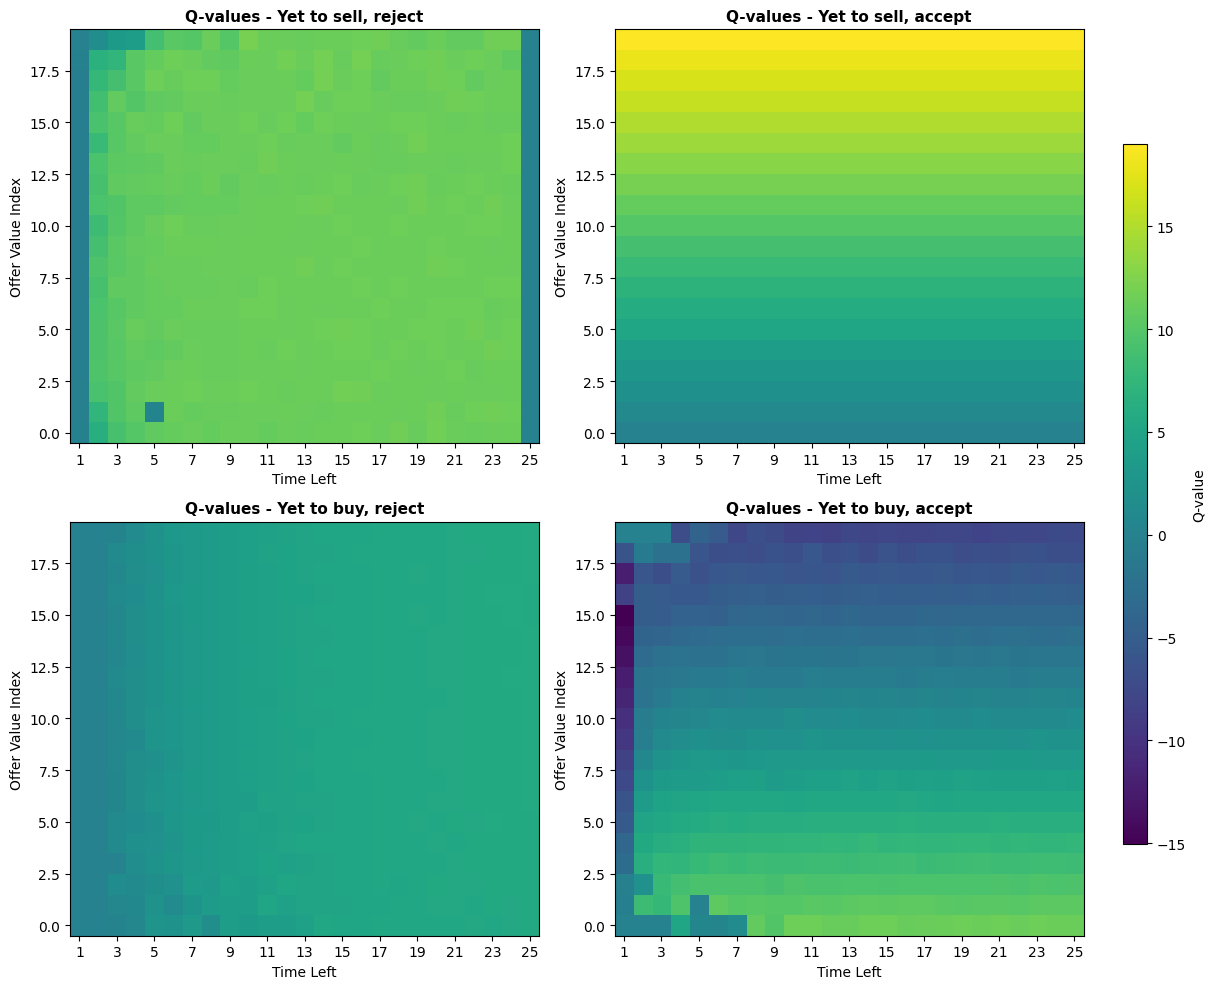

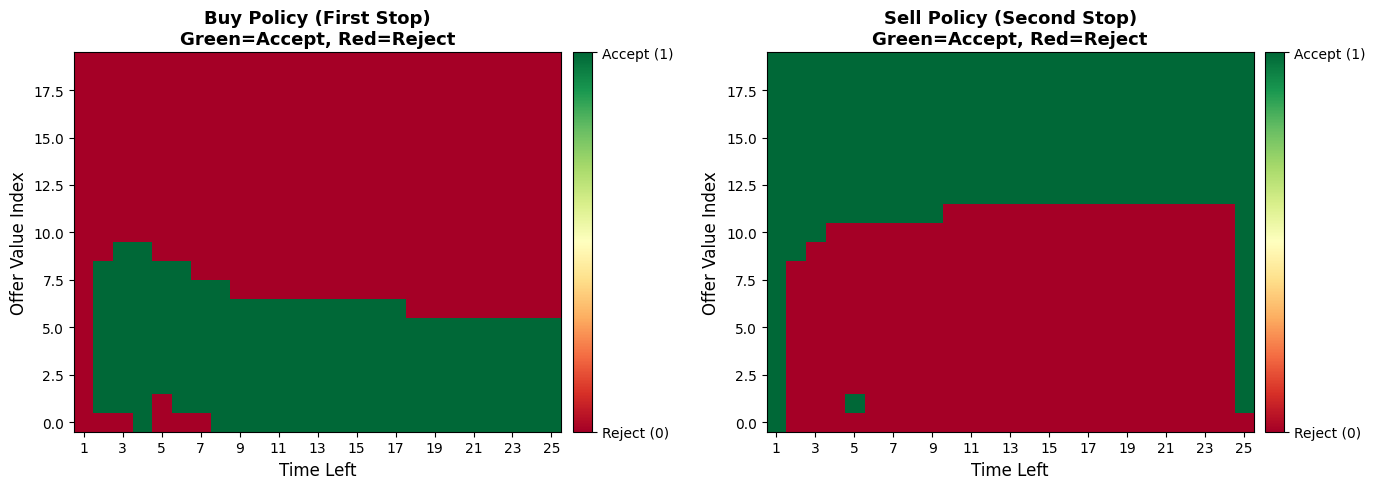


Q-Learning Policy Statistics:
Buy Policy - Accept rate: 33.60%
Sell Policy - Accept rate: 47.00%


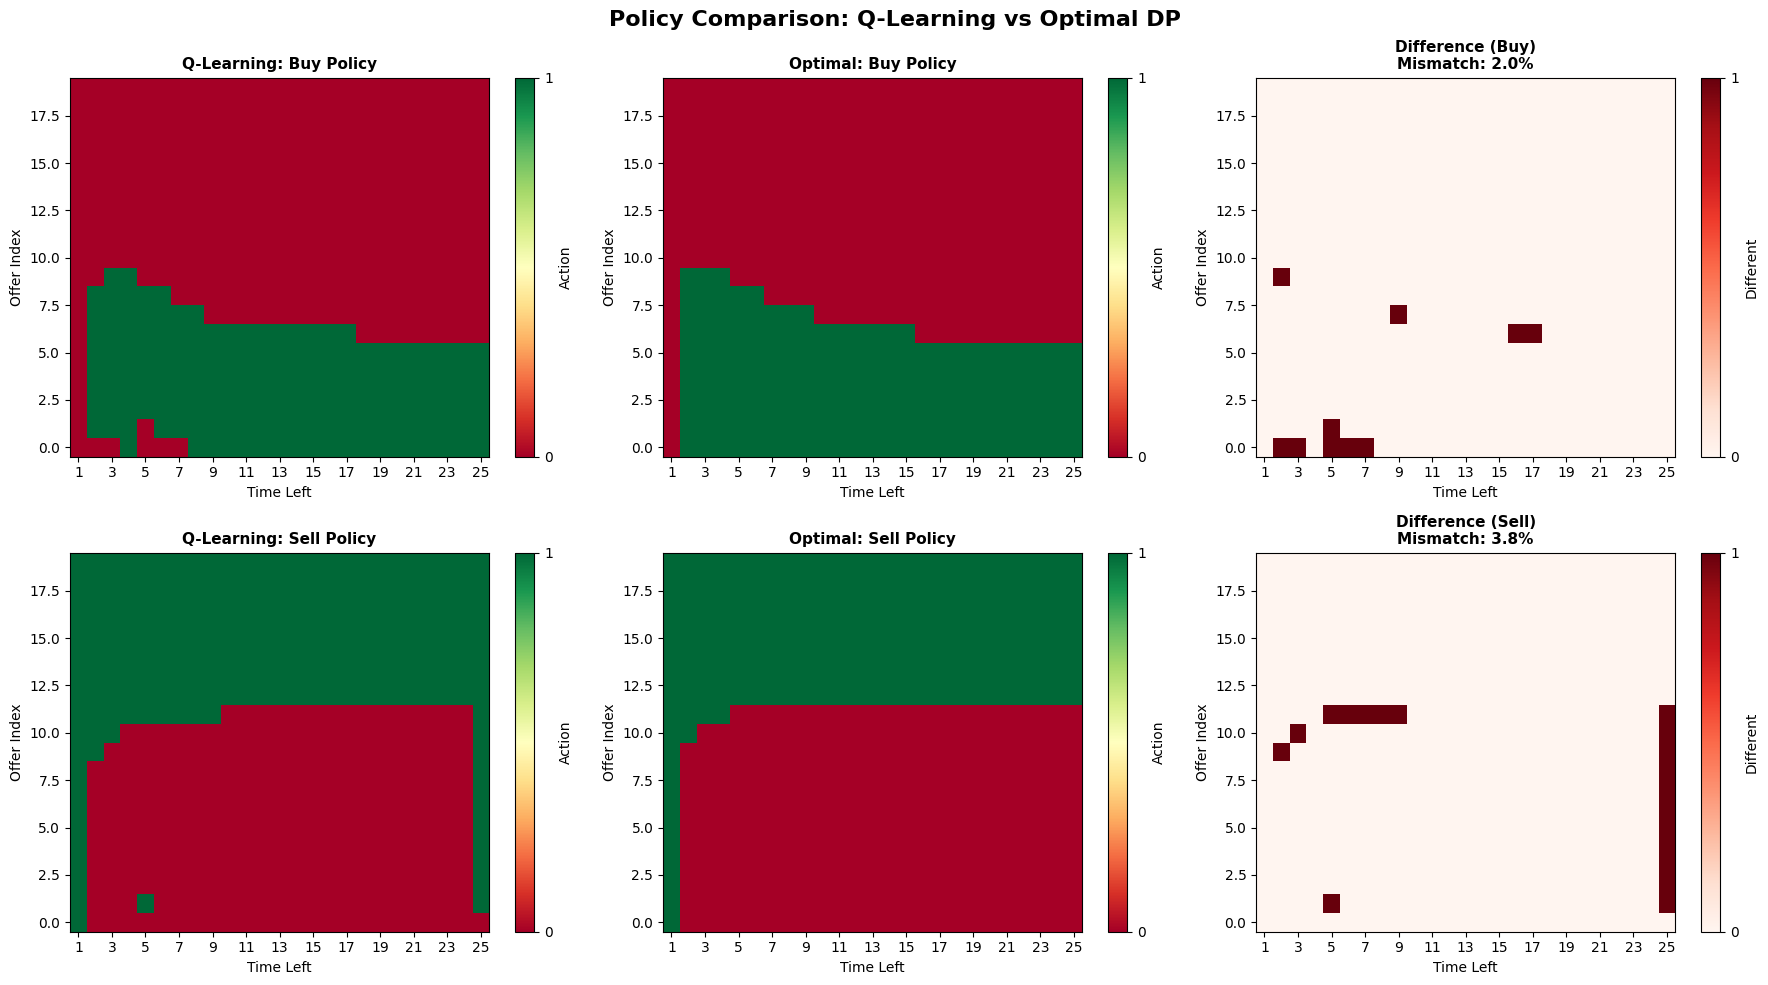


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 33.60%
  Optimal accept rate: 34.80%
  Agreement: 98.00%
  Mismatch: 2.00%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 47.00%
  Optimal accept rate: 43.20%
  Agreement: 96.20%
  Mismatch: 3.80%

Overall Policy Agreement: 97.10%


In [3]:
larger_env = BuySellEnv(
    n_states=20,
    max_time=25,
    holding_cost_per_step=0.5,
    transition_model='iid_gaussian',
    transition_params={'mean': 10.0, 'std': 3.0},
    seed=42
)
n_ep = 5000000
e_sched = linear_decay_schedule(1.0, 0.01, n_ep)
alpha_sched = linear_decay_schedule(1.0, 0.01, n_ep)
larger_agent = QLearningAgent(
    env=larger_env,
    alpha_schedule=alpha_sched,
    epsilon_schedule=e_sched,
)
larger_agent.train(env=larger_env, n_episodes=n_ep, verbose = 0 , use_tqdm=True)
larger_viz = visualizer(larger_env, larger_agent)
larger_viz.pipeline(compare_optimal=True)

Approach 1: Standard Q learning with the epsilon greedy policy.
Approach 2: Optimising for maximum information gain - keep rejecting offer till the final offer.

For same number of episodes on each one, calculate which one is likely to learn the optimal solution better. 

In [ ]:
# Import the max-info Q-learning variant and accept-reward environment
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.resolve()))

from algorithms.q_learning_max_info import QLearningMaxInfo
from accept_reward_env import AcceptRewardEnv

In [ ]:
# Create a simple accept-reward environment (classic secretary/house-hunting problem)
accept_env = AcceptRewardEnv(
    n_states=10,
    max_time=20,
    transition_model='iid_gaussian',
    transition_params={'mean': 5.0, 'std': 2.0},
    seed=42
)

print(f"Environment: {accept_env.n_states} states, {accept_env.max_time} time steps")
print(f"Offer values: {accept_env.offer_values}")
print(f"Problem: Accept one offer to maximize expected reward")

In [ ]:
# Training parameters
n_episodes = 10000
epsilon_schedule = linear_decay_schedule(1.0, 0.05, n_episodes // 2)
alpha_schedule = linear_decay_schedule(0.3, 0.05, n_episodes // 2)

print(f"\nTraining both approaches for {n_episodes} episodes...")
print("="*70)

# Approach 1: Regular Q-Learning
print("\n1. Training Regular Q-Learning (epsilon-greedy)...")
agent_regular = QLearningAgent(
    env=accept_env,
    alpha_schedule=alpha_schedule,
    epsilon_schedule=epsilon_schedule,
    gamma=1.0,
    seed=42
)
agent_regular.train(accept_env, n_episodes=n_episodes, verbose=0, use_tqdm=True)

# Approach 2: Max-Info Q-Learning
print("\n2. Training Max-Info Q-Learning (reject until last step)...")
agent_max_info = QLearningMaxInfo(
    env=accept_env,
    alpha_schedule=alpha_schedule,
    epsilon_schedule=epsilon_schedule,
    gamma=1.0,
    seed=42
)
agent_max_info.train(accept_env, n_episodes=n_episodes, verbose=0, use_tqdm=True)

print("\n" + "="*70)
print("Training complete!")

In [ ]:
# Get optimal policy
print("\nComputing optimal policy...")
V_opt, opt_policy = accept_env.solve_optimal_policy(verbose=True)

# Get learned policies
regular_policy = agent_regular.get_policy()
max_info_policy = agent_max_info.get_policy()

# Evaluate all three policies
print("\nEvaluating policies...")
evaluator_accept = PolicyEvaluator(accept_env)

results_regular = evaluator_accept.evaluate_policy(
    regular_policy,
    n_episodes=1000,
    policy_name="Regular Q-Learning",
    verbose=False,
    seed=42
)

results_max_info = evaluator_accept.evaluate_policy(
    max_info_policy,
    n_episodes=1000,
    policy_name="Max-Info Q-Learning",
    verbose=False,
    seed=42
)

results_optimal = evaluator_accept.evaluate_policy(
    opt_policy,
    n_episodes=1000,
    policy_name="Optimal",
    verbose=False,
    seed=42
)

In [ ]:
# Compute policy agreement with optimal
agreement_regular = np.mean(regular_policy == opt_policy)
agreement_max_info = np.mean(max_info_policy == opt_policy)

# Print comprehensive comparison
print("\n" + "="*80)
print("COMPARISON RESULTS: Regular Q-Learning vs Max-Info Q-Learning")
print("="*80)

print("\n1. PERFORMANCE (Evaluation Rewards)")
print("-" * 80)
print(f"{'Method':<30} {'Mean Reward':<15} {'Std':<10} {'Sharpe':<10} {'vs Optimal'}")
print("-" * 80)
print(f"{'Regular Q-Learning':<30} {results_regular['mean_reward']:<15.4f} "
      f"{results_regular['std_reward']:<10.4f} {results_regular['sharpe_ratio']:<10.4f} "
      f"{results_regular['mean_reward']/results_optimal['mean_reward']:>8.2%}")
print(f"{'Max-Info Q-Learning':<30} {results_max_info['mean_reward']:<15.4f} "
      f"{results_max_info['std_reward']:<10.4f} {results_max_info['sharpe_ratio']:<10.4f} "
      f"{results_max_info['mean_reward']/results_optimal['mean_reward']:>8.2%}")
print(f"{'Optimal':<30} {results_optimal['mean_reward']:<15.4f} "
      f"{results_optimal['std_reward']:<10.4f} {results_optimal['sharpe_ratio']:<10.4f} "
      f"{'100.0%':>8}")

improvement = ((results_max_info['mean_reward'] - results_regular['mean_reward']) / 
               results_regular['mean_reward'] * 100)
print(f"\nMax-Info improvement over Regular: {improvement:+.2f}%")

print("\n2. POLICY AGREEMENT WITH OPTIMAL")
print("-" * 80)
print(f"Regular Q-Learning:    {agreement_regular:.2%}")
print(f"Max-Info Q-Learning:   {agreement_max_info:.2%}")
print(f"Difference:            {(agreement_max_info - agreement_regular)*100:+.2f} percentage points")

print("\n3. LEARNING STATISTICS")
print("-" * 80)
print(f"Regular Q-Learning:")
print(f"  - Final 100-ep avg reward: {np.mean(agent_regular.episode_rewards[-100:]):.4f}")
print(f"  - Visit counts (states):   {agent_regular.visit_counts.sum():.0f} total visits")

print(f"\nMax-Info Q-Learning:")
print(f"  - Final 100-ep avg reward: {np.mean(agent_max_info.episode_rewards[-100:]):.4f}")
print(f"  - Visit counts (states):   {agent_max_info.visit_counts.sum():.0f} total visits")
print(f"  - Total forced rejects:    {agent_max_info.total_forced_rejects}")

print("\n" + "="*80)

In [ ]:
# Visualize policies side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Single-Stopping Policy Comparison', fontsize=16, fontweight='bold')

# Exclude time_left=0
regular_view = regular_policy[:, 1:, 1]
max_info_view = max_info_policy[:, 1:, 1]
opt_view = opt_policy[:, 1:, 1]

max_time = regular_view.shape[1]
time_ticks = np.arange(0, max_time, max(1, max_time//10))
time_labels = np.arange(1, max_time+1, max(1, max_time//10))

# Regular Q-Learning
im1 = axes[0].imshow(regular_view, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[0].set_title(f'Regular Q-Learning\nAgreement: {agreement_regular:.1%}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Left', fontsize=11)
axes[0].set_ylabel('Offer Index', fontsize=11)
axes[0].set_xticks(time_ticks)
axes[0].set_xticklabels(time_labels)
cbar1 = plt.colorbar(im1, ax=axes[0], ticks=[0, 1])
cbar1.set_ticklabels(['Reject', 'Accept'])

# Max-Info Q-Learning
im2 = axes[1].imshow(max_info_view, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[1].set_title(f'Max-Info Q-Learning\nAgreement: {agreement_max_info:.1%}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Left', fontsize=11)
axes[1].set_ylabel('Offer Index', fontsize=11)
axes[1].set_xticks(time_ticks)
axes[1].set_xticklabels(time_labels)
cbar2 = plt.colorbar(im2, ax=axes[1], ticks=[0, 1])
cbar2.set_ticklabels(['Reject', 'Accept'])

# Optimal
im3 = axes[2].imshow(opt_view, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[2].set_title('Optimal Policy', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Time Left', fontsize=11)
axes[2].set_ylabel('Offer Index', fontsize=11)
axes[2].set_xticks(time_ticks)
axes[2].set_xticklabels(time_labels)
cbar3 = plt.colorbar(im3, ax=axes[2], ticks=[0, 1])
cbar3.set_ticklabels(['Reject', 'Accept'])

plt.tight_layout()
plt.show()

In [ ]:
# Difference heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regular_view = regular_policy[:, 1:, 1]
max_info_view = max_info_policy[:, 1:, 1]
opt_view = opt_policy[:, 1:, 1]

# Difference: Regular vs Optimal
diff_regular = (regular_view != opt_view).astype(float)
im1 = axes[0].imshow(diff_regular, cmap='Reds', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[0].set_title(f'Regular Q-Learning vs Optimal\nMismatch: {diff_regular.mean():.1%}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Left', fontsize=11)
axes[0].set_ylabel('Offer Index', fontsize=11)
axes[0].set_xticks(time_ticks)
axes[0].set_xticklabels(time_labels)
plt.colorbar(im1, ax=axes[0], ticks=[0, 1], label='Different')

# Difference: Max-Info vs Optimal
diff_max_info = (max_info_view != opt_view).astype(float)
im2 = axes[1].imshow(diff_max_info, cmap='Reds', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[1].set_title(f'Max-Info Q-Learning vs Optimal\nMismatch: {diff_max_info.mean():.1%}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Left', fontsize=11)
axes[1].set_ylabel('Offer Index', fontsize=11)
axes[1].set_xticks(time_ticks)
axes[1].set_xticklabels(time_labels)
plt.colorbar(im2, ax=axes[1], ticks=[0, 1], label='Different')

plt.tight_layout()
plt.show()

print(f"\nPolicy Mismatch Summary:")
print(f"  Regular vs Optimal:  {diff_regular.mean():.2%}")
print(f"  Max-Info vs Optimal: {diff_max_info.mean():.2%}")
print(f"  Winner: {'Max-Info' if diff_max_info.mean() < diff_regular.mean() else 'Regular'}")

In [ ]:
# Learning curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

window = 100
regular_rewards = np.convolve(
    agent_regular.episode_rewards,
    np.ones(window)/window, mode='valid'
)
max_info_rewards = np.convolve(
    agent_max_info.episode_rewards,
    np.ones(window)/window, mode='valid'
)

# Learning curves
axes[0].plot(regular_rewards, label='Regular Q-Learning', alpha=0.8, linewidth=2)
axes[0].plot(max_info_rewards, label='Max-Info Q-Learning', alpha=0.8, linewidth=2)
axes[0].axhline(y=results_optimal['mean_reward'], color='red', linestyle='--', 
                linewidth=2, label='Optimal', alpha=0.7)
axes[0].set_xlabel('Episode', fontsize=11)
axes[0].set_ylabel(f'Average Reward ({window}-ep window)', fontsize=11)
axes[0].set_title('Learning Curves', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Final performance comparison
methods = ['Regular\nQ-Learning', 'Max-Info\nQ-Learning', 'Optimal']
mean_rewards = [
    results_regular['mean_reward'],
    results_max_info['mean_reward'],
    results_optimal['mean_reward']
]
std_rewards = [
    results_regular['std_reward'],
    results_max_info['std_reward'],
    results_optimal['std_reward']
]
colors = ['blue', 'green', 'red']

axes[1].bar(methods, mean_rewards, yerr=std_rewards, capsize=5, alpha=0.7, color=colors)
axes[1].set_ylabel('Mean Reward', fontsize=11)
axes[1].set_title('Performance Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [4]:
# Compare Vanilla Q-Learning vs Constrained Q-Learning on BuySellEnv

# Create environment
constraint_env = BuySellEnv(
    n_states=20,
    max_time=25,
    holding_cost_per_step=0.5,
    transition_model='iid_gaussian',
    transition_params={'mean': 10.0, 'std': 3.0},
    seed=42
)

# Training parameters
n_eps = 100000
epsilon_sched = linear_decay_schedule(1.0, 0.05, n_eps // 2)
alpha_sched = linear_decay_schedule(0.3, 0.05, n_eps // 2)

print("Training Vanilla Q-Learning...")
agent_vanilla = QLearningAgentVanilla(
    env=constraint_env,
    alpha_schedule=alpha_sched,
    epsilon_schedule=epsilon_sched,
    gamma=1.0,
    seed=42
)
agent_vanilla.train(constraint_env, n_episodes=n_eps, verbose=0, use_tqdm=True)

print("\nTraining Constrained Q-Learning (monotonicity in time)...")
agent_constrained = QLearningAgentConstraint(
    env=constraint_env,
    alpha_schedule=alpha_sched,
    epsilon_schedule=epsilon_sched,
    gamma=1.0,
    seed=42
)
agent_constrained.train(constraint_env, n_episodes=n_eps, verbose=0, use_tqdm=True)

print("\nTraining complete!")

Training Vanilla Q-Learning...


Training:   0%|                                                     | 0/100000 [00:00<?, ?episode/s]


Training Constrained Q-Learning (monotonicity in time)...


Training:   0%|                                                     | 0/100000 [00:00<?, ?episode/s]


Training complete!


In [14]:
# Get optimal policy
V_opt_c, opt_policy_c = constraint_env.solve_optimal_policy(verbose=True)

# Get learned policies
vanilla_policy = agent_vanilla.get_policy()
constrained_policy = agent_constrained.get_policy()

# Evaluate policies
evaluator_c = PolicyEvaluator(constraint_env)

results_vanilla = evaluator_c.evaluate_policy(
    vanilla_policy, n_episodes=5000, policy_name="Vanilla", verbose=False, seed=42
)
results_constrained = evaluator_c.evaluate_policy(
    constrained_policy, n_episodes=5000, policy_name="Constrained", verbose=False, seed=42
)
results_opt_c = evaluator_c.evaluate_policy(
    opt_policy_c, n_episodes=5000, policy_name="Optimal", verbose=False, seed=42
)

# Compute agreement
agreement_vanilla = np.mean(vanilla_policy == opt_policy_c)
agreement_constrained = np.mean(constrained_policy == opt_policy_c)

print("\n" + "="*80)
print("COMPARISON: Vanilla Q-Learning vs Constrained Q-Learning")
print("="*80)
print(f"\n{'Method':<30} {'Mean Reward':<15} {'Std':<10} {'vs Optimal':<12} {'Agreement'}")
print("-"*80)
print(f"{'Vanilla Q-Learning':<30} {results_vanilla['mean_reward']:<15.4f} "
      f"{results_vanilla['std_reward']:<10.4f} "
      f"{results_vanilla['mean_reward']/results_opt_c['mean_reward']*100:>8.2f}%    {agreement_vanilla:.2%}")
print(f"{'Constrained Q-Learning':<30} {results_constrained['mean_reward']:<15.4f} "
      f"{results_constrained['std_reward']:<10.4f} "
      f"{results_constrained['mean_reward']/results_opt_c['mean_reward']*100:>8.2f}%    {agreement_constrained:.2%}")
print(f"{'Optimal':<30} {results_opt_c['mean_reward']:<15.4f} "
      f"{results_opt_c['std_reward']:<10.4f} {'100.00%':>12}    {'100.00%'}")
print("="*80)

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 7.4551
  Buy (stop 1) accept rate: 34.80%
  Sell (stop 2) accept rate: 43.20%

COMPARISON: Vanilla Q-Learning vs Constrained Q-Learning

Method                         Mean Reward     Std        vs Optimal   Agreement
--------------------------------------------------------------------------------
Vanilla Q-Learning             5.3081          3.0536        78.41%    77.88%
Constrained Q-Learning         5.1311          2.9085        75.79%    77.69%
Optimal                        6.7698          2.7722          100.00%    100.00%

COMPARISON: Vanilla Q-Learning vs Constrained Q-Learning

Method                         Mean Reward     Std        vs Optimal   Agreement
--------------------------------------------------------------------------------
Vanilla Q-Learning             5.3081          3.0536        78.41%    77.88%
Constrained Q-Learning         5.1311          2.9085        75.79%    77.69%
Optimal    

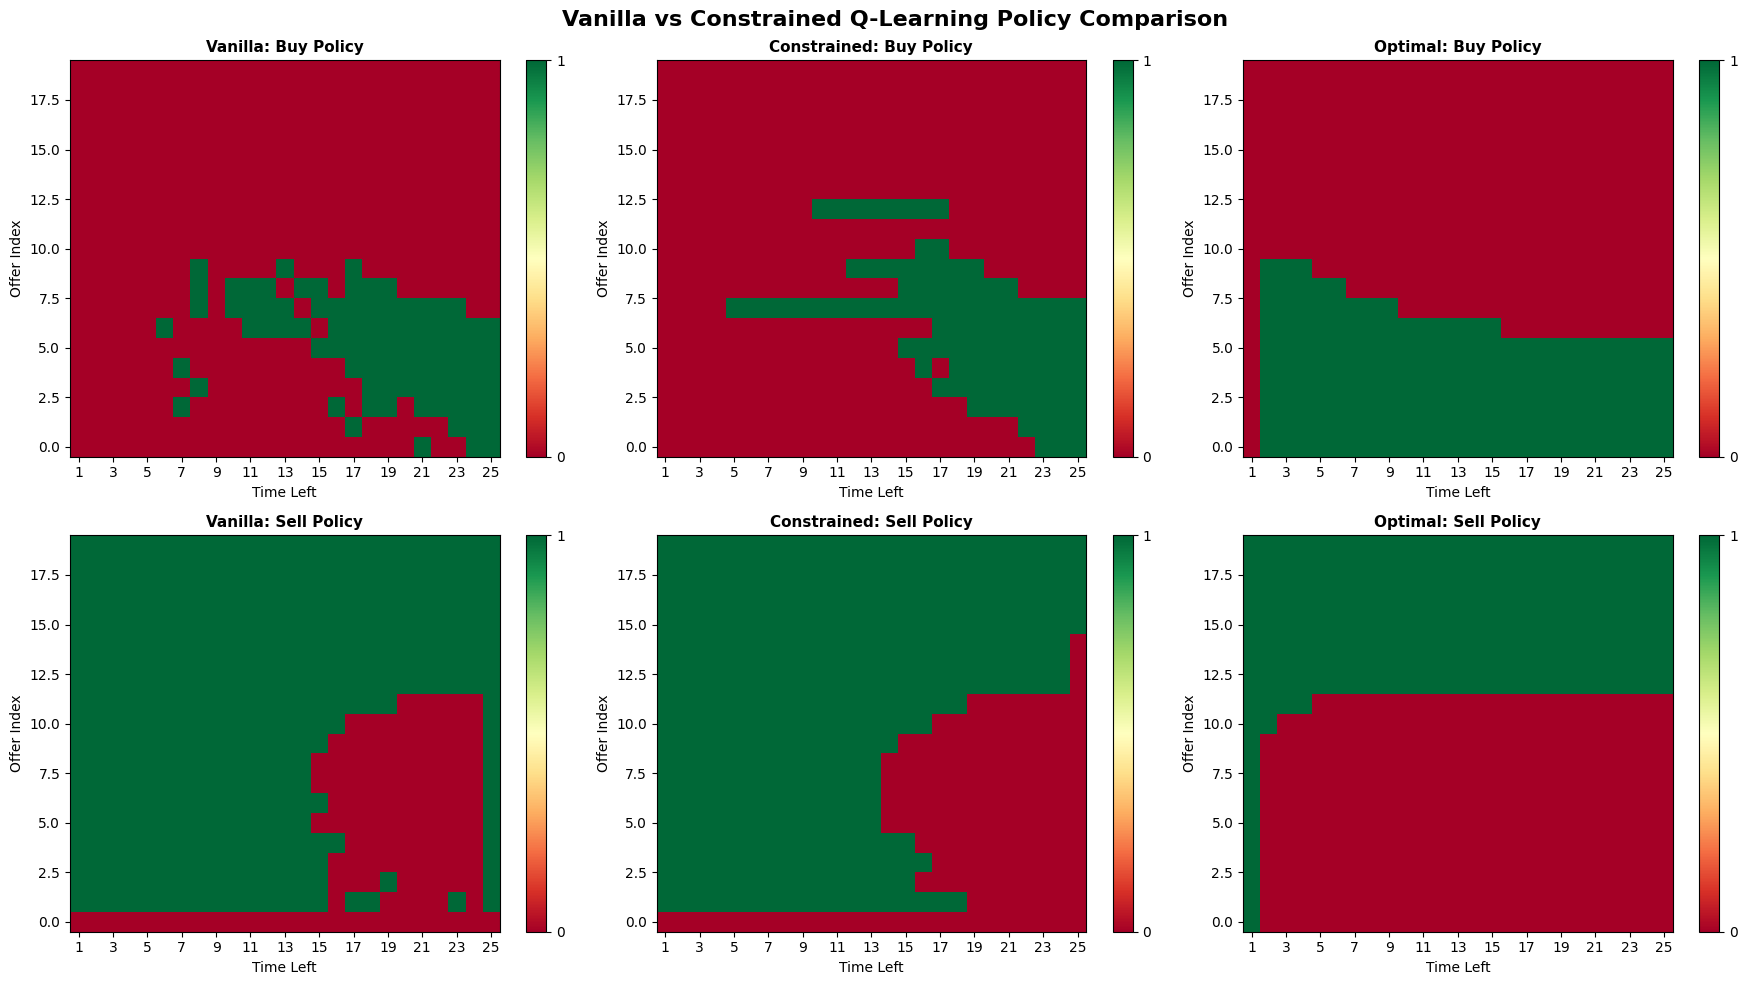

In [15]:
# Visualize policy comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Vanilla vs Constrained Q-Learning Policy Comparison', fontsize=16, fontweight='bold')

# Exclude time_left=0
vanilla_buy = vanilla_policy[:, 1:, 2]
vanilla_sell = vanilla_policy[:, 1:, 1]
constrained_buy = constrained_policy[:, 1:, 2]
constrained_sell = constrained_policy[:, 1:, 1]
opt_buy = opt_policy_c[:, 1:, 2]
opt_sell = opt_policy_c[:, 1:, 1]

max_time = vanilla_buy.shape[1]
time_ticks = np.arange(0, max_time, max(1, max_time//10))
time_labels = np.arange(1, max_time+1, max(1, max_time//10))

# Row 1: Buy policies
im1 = axes[0, 0].imshow(vanilla_buy, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[0, 0].set_title('Vanilla: Buy Policy', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Time Left'); axes[0, 0].set_ylabel('Offer Index')
axes[0, 0].set_xticks(time_ticks); axes[0, 0].set_xticklabels(time_labels)
plt.colorbar(im1, ax=axes[0, 0], ticks=[0, 1])

im2 = axes[0, 1].imshow(constrained_buy, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[0, 1].set_title('Constrained: Buy Policy', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Time Left'); axes[0, 1].set_ylabel('Offer Index')
axes[0, 1].set_xticks(time_ticks); axes[0, 1].set_xticklabels(time_labels)
plt.colorbar(im2, ax=axes[0, 1], ticks=[0, 1])

im3 = axes[0, 2].imshow(opt_buy, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[0, 2].set_title('Optimal: Buy Policy', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('Time Left'); axes[0, 2].set_ylabel('Offer Index')
axes[0, 2].set_xticks(time_ticks); axes[0, 2].set_xticklabels(time_labels)
plt.colorbar(im3, ax=axes[0, 2], ticks=[0, 1])

# Row 2: Sell policies
im4 = axes[1, 0].imshow(vanilla_sell, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[1, 0].set_title('Vanilla: Sell Policy', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Time Left'); axes[1, 0].set_ylabel('Offer Index')
axes[1, 0].set_xticks(time_ticks); axes[1, 0].set_xticklabels(time_labels)
plt.colorbar(im4, ax=axes[1, 0], ticks=[0, 1])

im5 = axes[1, 1].imshow(constrained_sell, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[1, 1].set_title('Constrained: Sell Policy', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Time Left'); axes[1, 1].set_ylabel('Offer Index')
axes[1, 1].set_xticks(time_ticks); axes[1, 1].set_xticklabels(time_labels)
plt.colorbar(im5, ax=axes[1, 1], ticks=[0, 1])

im6 = axes[1, 2].imshow(opt_sell, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[1, 2].set_title('Optimal: Sell Policy', fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel('Time Left'); axes[1, 2].set_ylabel('Offer Index')
axes[1, 2].set_xticks(time_ticks); axes[1, 2].set_xticklabels(time_labels)
plt.colorbar(im6, ax=axes[1, 2], ticks=[0, 1])

plt.tight_layout()
plt.show()

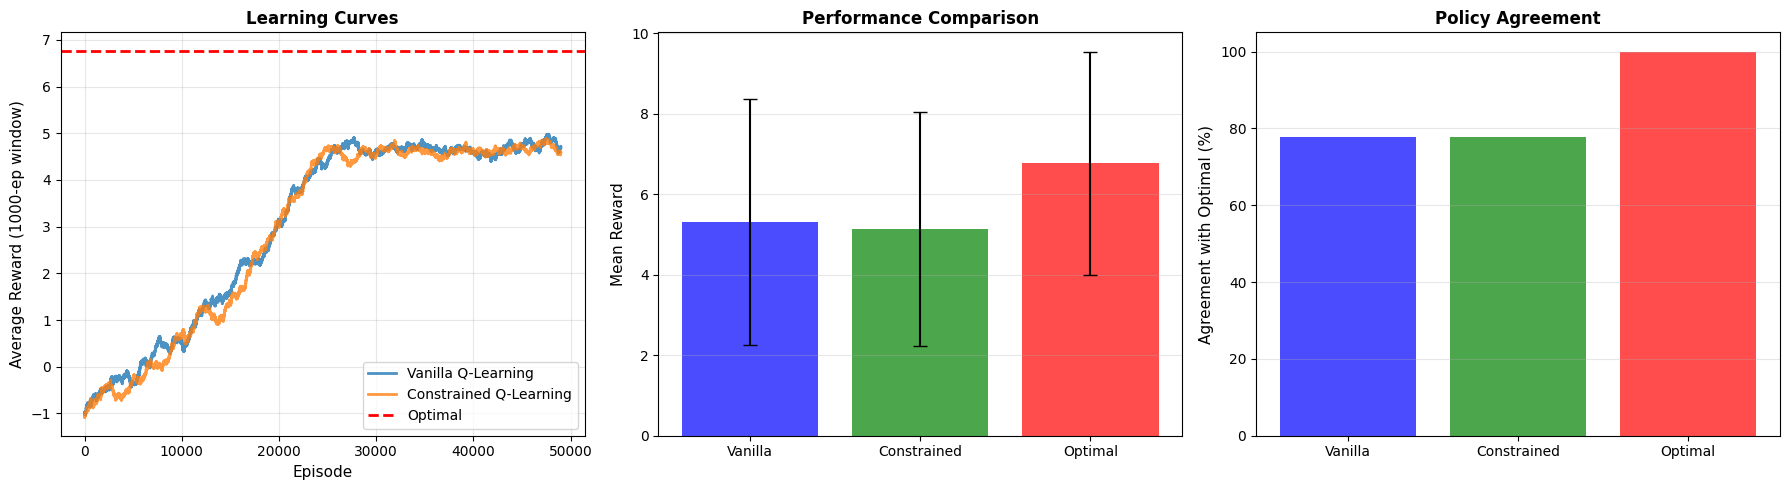


Winner: Vanilla Q-Learning
Improvement: -0.19 percentage points in policy agreement


In [16]:
# Learning curves and performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learning curves
window = 1000
vanilla_rewards = np.convolve(agent_vanilla.episode_rewards, np.ones(window)/window, mode='valid')
constrained_rewards = np.convolve(agent_constrained.episode_rewards, np.ones(window)/window, mode='valid')

axes[0].plot(vanilla_rewards, label='Vanilla Q-Learning', alpha=0.8, linewidth=2)
axes[0].plot(constrained_rewards, label='Constrained Q-Learning', alpha=0.8, linewidth=2)
axes[0].axhline(y=results_opt_c['mean_reward'], color='red', linestyle='--', linewidth=2, label='Optimal')
axes[0].set_xlabel('Episode', fontsize=11)
axes[0].set_ylabel(f'Average Reward ({window}-ep window)', fontsize=11)
axes[0].set_title('Learning Curves', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Performance bar chart
methods = ['Vanilla', 'Constrained', 'Optimal']
mean_rewards = [results_vanilla['mean_reward'], results_constrained['mean_reward'], results_opt_c['mean_reward']]
std_rewards = [results_vanilla['std_reward'], results_constrained['std_reward'], results_opt_c['std_reward']]
colors = ['blue', 'green', 'red']

axes[1].bar(methods, mean_rewards, yerr=std_rewards, capsize=5, alpha=0.7, color=colors)
axes[1].set_ylabel('Mean Reward', fontsize=11)
axes[1].set_title('Performance Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

# Policy agreement bar chart
agreements = [agreement_vanilla * 100, agreement_constrained * 100, 100]
axes[2].bar(methods, agreements, alpha=0.7, color=colors)
axes[2].set_ylabel('Agreement with Optimal (%)', fontsize=11)
axes[2].set_title('Policy Agreement', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 105)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nWinner: {'Constrained' if agreement_constrained > agreement_vanilla else 'Vanilla'} Q-Learning")
print(f"Improvement: {(agreement_constrained - agreement_vanilla)*100:+.2f} percentage points in policy agreement")


Testing: IID Gaussian


Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

ENV: IID Gaussian


Evaluating Vanilla: 100%|██████████| 1000/1000 [00:00<00:00, 9023.54it/s]



Evaluation Summary: Vanilla
Episodes: 1000

Reward Statistics:
  Mean:          4.0901
  Std:           1.7091
  Sharpe:        2.3932
  Median:        3.9500
  Min:          -3.3500
  Max:           8.8500

Episode Length:
  Mean:            6.74
  Std:             2.68

Buy-Sell Specific Metrics:
  Completion rate:   99.60%
  Mean buy price:      2.7922
  Mean sell price:     7.0703
  Mean profit:         4.2781
  Mean holding time:     3.43



Evaluating Constrained: 100%|██████████| 1000/1000 [00:00<00:00, 10008.00it/s]




Evaluation Summary: Constrained
Episodes: 1000

Reward Statistics:
  Mean:          4.1765
  Std:           1.7161
  Sharpe:        2.4338
  Median:        3.9500
  Min:          -3.4000
  Max:           8.8500

Episode Length:
  Mean:            7.50
  Std:             2.47

Buy-Sell Specific Metrics:
  Completion rate:   100.00%
  Mean buy price:      2.7420
  Mean sell price:     7.1260
  Mean profit:         4.3840
  Mean holding time:     4.15


Policy Comparison: Vanilla vs Constrained

Metric                            Vanilla     Constrained     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        4.0901          4.1765   +0.0864 (+2.1%)   Constrained
Std Reward                         1.7091          1.7161   +0.0070 (+0.4%)      Vanilla
Sharpe Ratio                       2.3932          2.4338   +0.0406 (+1.7%)   Constrained
Median Reward                      3.9500          3.9500   +0.0000 (+0.0%)

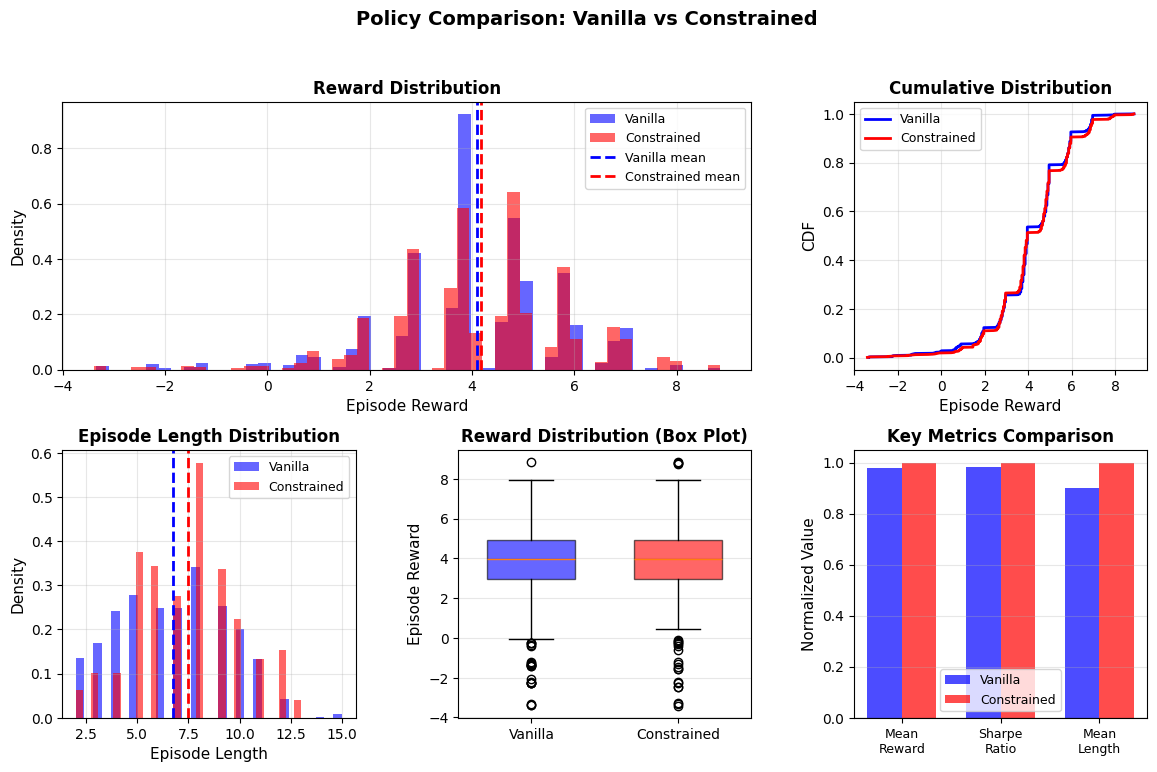


Testing: IID Uniform


Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

ENV: IID Uniform


Evaluating Vanilla: 100%|██████████| 1000/1000 [00:00<00:00, 9127.64it/s]



Evaluation Summary: Vanilla
Episodes: 1000

Reward Statistics:
  Mean:          6.3133
  Std:           1.9962
  Sharpe:        3.1626
  Median:        6.8000
  Min:          -3.2000
  Max:           8.9500

Episode Length:
  Mean:            6.39
  Std:             2.54

Buy-Sell Specific Metrics:
  Completion rate:   99.90%
  Mean buy price:      1.2933
  Mean sell price:     7.7858
  Mean profit:         6.4925
  Mean holding time:     3.46



Evaluating Constrained: 100%|██████████| 1000/1000 [00:00<00:00, 11882.05it/s]



Evaluation Summary: Constrained
Episodes: 1000

Reward Statistics:
  Mean:          6.5750
  Std:           1.8822
  Sharpe:        3.4932
  Median:        6.9000
  Min:          -2.3500
  Max:           8.9500

Episode Length:
  Mean:            6.91
  Std:             2.87

Buy-Sell Specific Metrics:
  Completion rate:   99.80%
  Mean buy price:      1.2014
  Mean sell price:     7.9790
  Mean profit:         6.7776
  Mean holding time:     3.79


Policy Comparison: Vanilla vs Constrained

Metric                            Vanilla     Constrained     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        6.3133          6.5750   +0.2618 (+4.1%)   Constrained
Std Reward                         1.9962          1.8822   -0.1140 (-5.7%)   Constrained
Sharpe Ratio                       3.1626          3.4932   +0.3307 (+10.5%)   Constrained
Median Reward                      6.8000          6.9000   +0.1000 (+1.5%

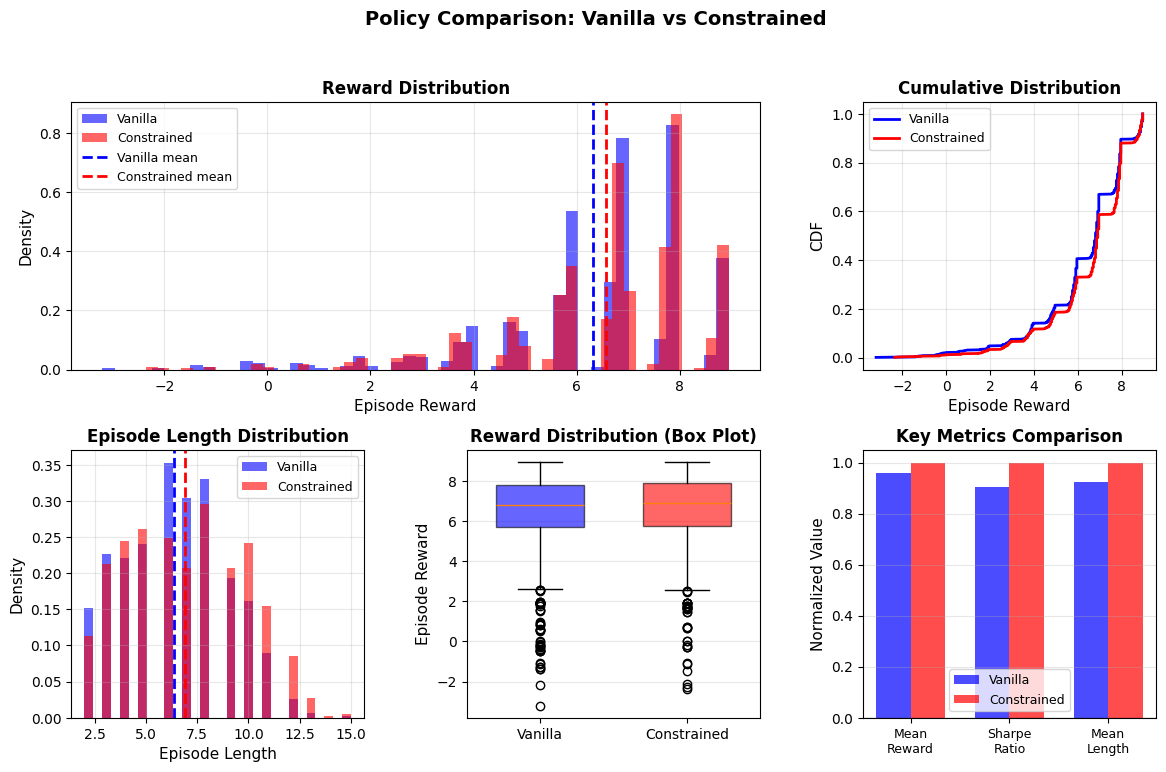


Testing: Random Walk (p_up=0.6)


Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

ENV: Random Walk (p_up=0.6)


Evaluating Vanilla: 100%|██████████| 1000/1000 [00:00<00:00, 8041.03it/s]



Evaluation Summary: Vanilla
Episodes: 1000

Reward Statistics:
  Mean:          2.2165
  Std:           1.3961
  Sharpe:        1.5877
  Median:        2.5500
  Min:          -1.7000
  Max:           4.7500

Episode Length:
  Mean:            9.05
  Std:             2.32

Buy-Sell Specific Metrics:
  Completion rate:   100.00%
  Mean buy price:      0.7750
  Mean sell price:     3.3940
  Mean profit:         2.6190
  Mean holding time:     8.05



Evaluating Constrained: 100%|██████████| 1000/1000 [00:00<00:00, 7460.02it/s]




Evaluation Summary: Constrained
Episodes: 1000

Reward Statistics:
  Mean:          2.5436
  Std:           1.7289
  Sharpe:        1.4712
  Median:        2.5500
  Min:          -1.7500
  Max:           6.6500

Episode Length:
  Mean:           10.80
  Std:             2.14

Buy-Sell Specific Metrics:
  Completion rate:   99.40%
  Mean buy price:      0.7750
  Mean sell price:     3.8320
  Mean profit:         3.0573
  Mean holding time:     9.78


Policy Comparison: Vanilla vs Constrained

Metric                            Vanilla     Constrained     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        2.2165          2.5436   +0.3271 (+14.8%)   Constrained
Std Reward                         1.3961          1.7289   +0.3329 (+23.8%)      Vanilla
Sharpe Ratio                       1.5877          1.4712   -0.1165 (-7.3%)      Vanilla
Median Reward                      2.5500          2.5500   +0.0000 (+0.0%)

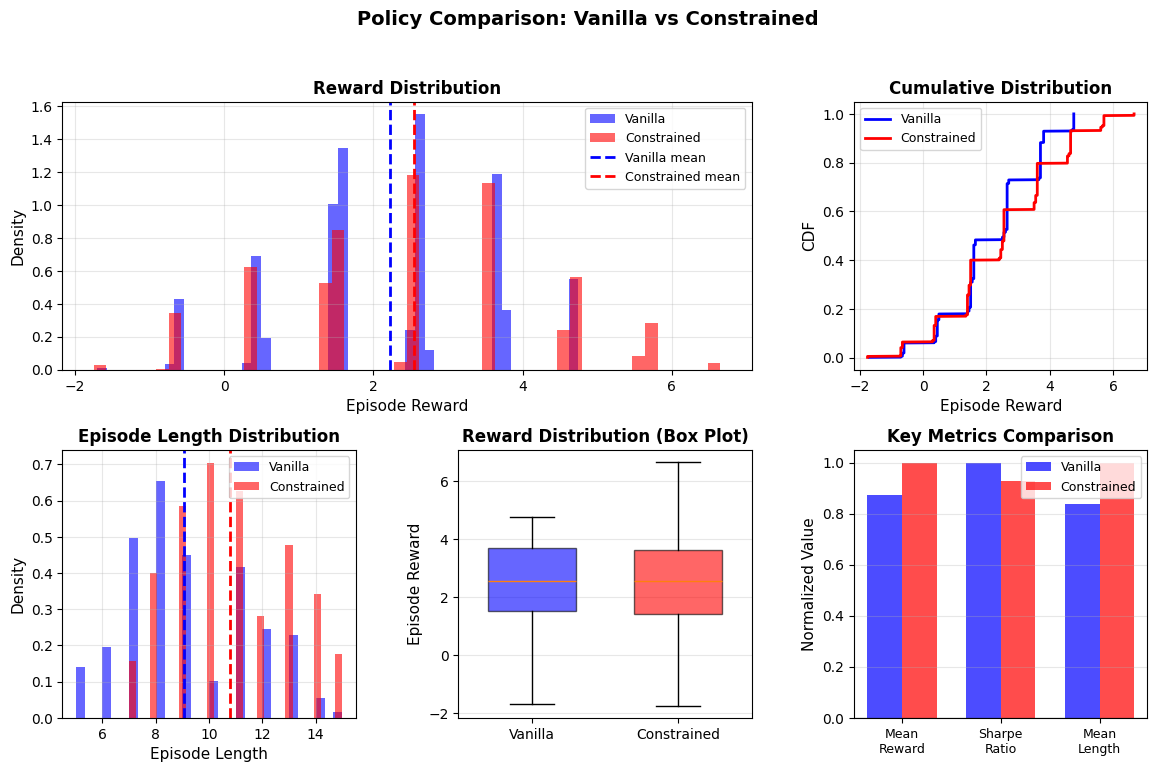


Testing: Random_Walk (p_up=0.4)


Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

Training:   0%|                                                      | 0/20000 [00:00<?, ?episode/s]

ENV: Random_Walk (p_up=0.4)


Evaluating Vanilla: 100%|██████████| 1000/1000 [00:00<00:00, 4864.11it/s]



Evaluation Summary: Vanilla
Episodes: 1000

Reward Statistics:
  Mean:          1.4892
  Std:           0.7025
  Sharpe:        2.1200
  Median:        1.7000
  Min:          -0.7000
  Max:           2.8500

Episode Length:
  Mean:            8.68
  Std:             3.97

Buy-Sell Specific Metrics:
  Completion rate:   94.20%
  Mean buy price:      0.0000
  Mean sell price:     1.8609
  Mean profit:         1.8609
  Mean holding time:     5.60



Evaluating Constrained: 100%|██████████| 1000/1000 [00:00<00:00, 7975.48it/s]




Evaluation Summary: Constrained
Episodes: 1000

Reward Statistics:
  Mean:          1.4440
  Std:           1.0890
  Sharpe:        1.3260
  Median:        1.5500
  Min:          -2.3500
  Max:           2.8500

Episode Length:
  Mean:            9.90
  Std:             3.10

Buy-Sell Specific Metrics:
  Completion rate:   98.90%
  Mean buy price:      0.3687
  Mean sell price:     2.2042
  Mean profit:         1.8322
  Mean holding time:     7.31


Policy Comparison: Vanilla vs Constrained

Metric                            Vanilla     Constrained     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        1.4892          1.4440   -0.0453 (-3.0%)      Vanilla
Std Reward                         0.7025          1.0890   +0.3865 (+55.0%)      Vanilla
Sharpe Ratio                       2.1200          1.3260   -0.7940 (-37.5%)      Vanilla
Median Reward                      1.7000          1.5500   -0.1500 (-8.8%) 

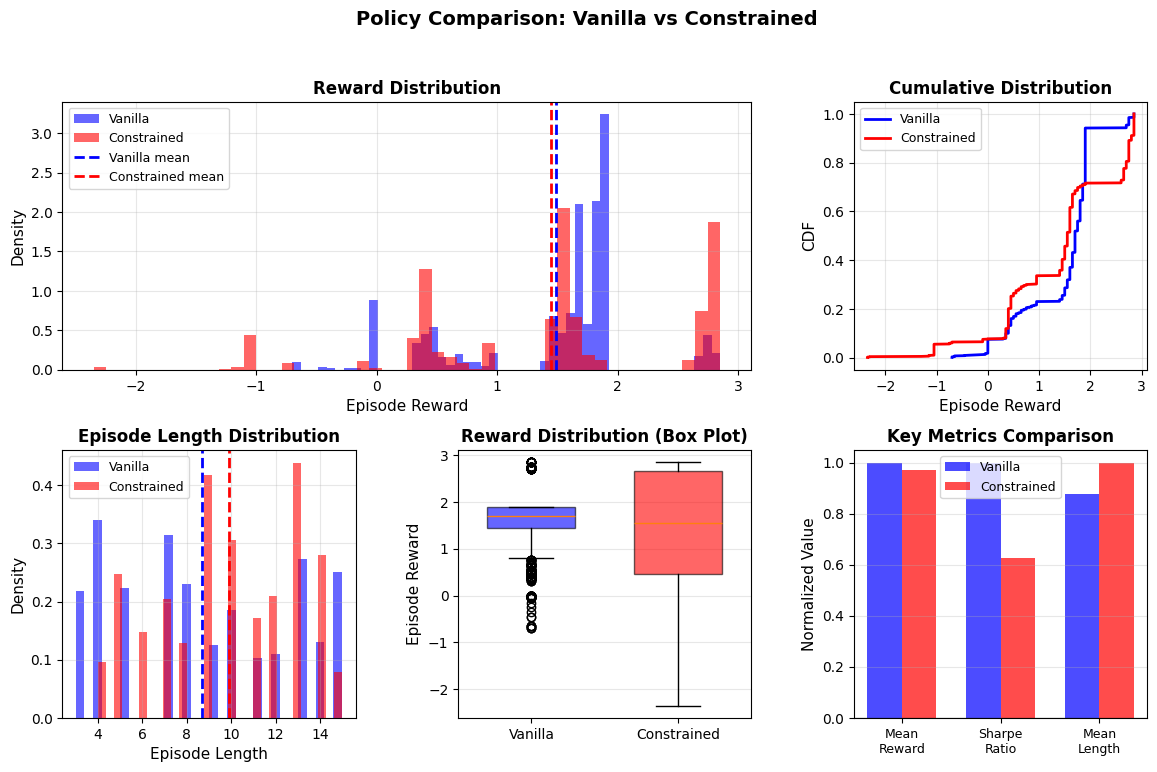


Testing: Brownian Motion


ValueError: Unknown transition model: brownian_motion

In [ ]:
# Test on multiple scenarios
scenarios = [
    ('IID Gaussian', 'iid_gaussian', {'mean': 5.0, 'std': 2.0}),
    ('IID Uniform', 'iid', None),
    ('Random Walk (p_up=0.6)', 'random_walk', {'p_up': 0.6, 'p_down': 0.4}),
    ('Random Walk (p_up=0.4)', 'random_walk', {'p_up': 0.4, 'p_down': 0.6}),
    ('Random Walk (p_up=0.5)', 'random_walk', {'p_up': 0.5, 'p_down': 0.5}),
    ('Brownian Motion', 'brownian', {})

]

results_comparison = []

for name, model, params in scenarios:
    print(f"\nTesting: {name}")
    
    test_env = BuySellEnv(
        n_states=10, max_time=15, holding_cost_per_step=0.05,
        transition_model=model, transition_params=params, seed=42
    )
    
    # Train both agents
    agent_v = QLearningAgentVanilla(env=test_env, alpha_schedule=alpha_sched, 
                                     epsilon_schedule=epsilon_sched, gamma=1.0, seed=42)
    agent_c = QLearningAgentConstraint(env=test_env, alpha_schedule=alpha_sched,
                                        epsilon_schedule=epsilon_sched, gamma=1.0, seed=42)
    
    agent_v.train(test_env, n_episodes=n_eps, verbose=0, use_tqdm=True)
    agent_c.train(test_env, n_episodes=n_eps, verbose=0, use_tqdm=True)
    
    # Get optimal and evaluate
    _, opt_p = test_env.solve_optimal_policy(verbose=False)
    ev = PolicyEvaluator(test_env)
    
    r_v = ev.evaluate_policy(agent_v.get_policy(), n_episodes=2000, verbose=False, seed=42)
    r_c = ev.evaluate_policy(agent_c.get_policy(), n_episodes=2000, verbose=False, seed=42)
    r_o = ev.evaluate_policy(opt_p, n_episodes=2000, verbose=False, seed=42)

    print(f"ENV: {name}")
    ev.compare_policies(policy1=agent_v.get_policy(), policy2=agent_c.get_policy(), policy1_name='Vanilla', policy2_name='Constrained')
    ev.plot_comparison()
    
    results_comparison.append({
        'scenario': name,
        'vanilla_reward': r_v['mean_reward'],
        'constrained_reward': r_c['mean_reward'],
        'optimal_reward': r_o['mean_reward'],
        'vanilla_agreement': np.mean(agent_v.get_policy() == opt_p),
        'constrained_agreement': np.mean(agent_c.get_policy() == opt_p),
    })

# Summary table
print("\n" + "="*90)
print("MULTI-SCENARIO COMPARISON SUMMARY")
print("="*90)
print(f"{'Scenario':<25} {'Vanilla %Opt':<15} {'Constrained %Opt':<18} {'Winner':<15} {'Agreement Δ'}")
print("-"*90)
for r in results_comparison:
    v_pct = r['vanilla_reward'] / r['optimal_reward'] * 100
    c_pct = r['constrained_reward'] / r['optimal_reward'] * 100
    winner = 'Constrained' if c_pct > v_pct else 'Vanilla' if v_pct > c_pct else 'Tie'
    delta = (r['constrained_agreement'] - r['vanilla_agreement']) * 100
    print(f"{r['scenario']:<25} {v_pct:<15.2f} {c_pct:<18.2f} {winner:<15} {delta:+.2f}%")
print("="*90)

### Compare Q-Learning Methods: Vanilla vs N-Step WIS vs Tree Backup

In [ ]:
def compare_q_methods(env, env_name, n_episodes=20000, n_step=3, eval_episodes=2000):
    """
    Compare Vanilla Q-Learning, WIS, and Tree Backup on a given environment.
    """
    print(f"\n{'='*70}")
    print(f"Environment: {env_name}")
    print(f"{'='*70}")
    
    # # Schedules
    # eps_sched = linear_decay_schedule(1.0, 0.05, n_episodes // 2)
    # alpha_sched = linear_decay_schedule(0.3, 0.05, n_episodes // 2)
    
    # Train Vanilla Q-Learning
    print("Training Vanilla Q-Learning...")
    agent_vanilla = QLearningAgent(
        env=env, alpha_schedule=alpha_sched, epsilon = 1.0 , gamma=1.0, seed=42
    )
    agent_vanilla.train(env, n_episodes=n_episodes, verbose=0, use_tqdm=True)
    
    # Train WIS
    print(f"Training {n_step}-Step WIS...")
    agent_wis = OffPolicyWISAgent(
        env=env, n_step=n_step, alpha_schedule=alpha_sched, epsilon = 1.0 , gamma=1.0, seed=42
    )
    agent_wis.train(env, n_episodes=n_episodes, verbose=0, use_tqdm=True)
    
    # Train Tree Backup
    print(f"Training {n_step}-Step Tree Backup...")
    agent_tree = TreeBackupAgent(
        env=env, n_step=n_step, alpha_schedule=alpha_sched, epsilon = 1.0 , gamma=1.0, seed=42
    )
    agent_tree.train(env, n_episodes=n_episodes, verbose=0, use_tqdm=True)
    
    # Get optimal policy
    _, opt_policy = env.solve_optimal_policy(verbose=False)
    
    # Evaluate
    evaluator = PolicyEvaluator(env)
    r_vanilla = evaluator.evaluate_policy(agent_vanilla.get_policy(), n_episodes=eval_episodes, verbose=False, seed=42)
    r_wis = evaluator.evaluate_policy(agent_wis.get_policy(), n_episodes=eval_episodes, verbose=False, seed=42)
    r_tree = evaluator.evaluate_policy(agent_tree.get_policy(), n_episodes=eval_episodes, verbose=False, seed=42)
    r_opt = evaluator.evaluate_policy(opt_policy, n_episodes=eval_episodes, verbose=False, seed=42)
    
    # Compute agreements
    agree_vanilla = np.mean(agent_vanilla.get_policy() == opt_policy)
    agree_wis = np.mean(agent_wis.get_policy() == opt_policy)
    agree_tree = np.mean(agent_tree.get_policy() == opt_policy)
    
    return {
        'env_name': env_name,
        'vanilla': {'reward': r_vanilla['mean_reward'], 'agreement': agree_vanilla, 'agent': agent_vanilla},
        'wis': {'reward': r_wis['mean_reward'], 'agreement': agree_wis, 'agent': agent_wis},
        'tree': {'reward': r_tree['mean_reward'], 'agreement': agree_tree, 'agent': agent_tree},
        'optimal': {'reward': r_opt['mean_reward']},
        'opt_policy': opt_policy
    }

In [4]:
# Define test environments
test_envs = [
    # IID case
    ('IID Gaussian', BuySellEnv(
        n_states=10, max_time=15, holding_cost_per_step=0.05,
        transition_model='iid_gaussian', transition_params={'mean': 5.0, 'std': 2.0}, seed=42
    )),
    # Markovian cases
    ('Random Walk (Balanced)', BuySellEnv(
        n_states=10, max_time=15, holding_cost_per_step=0.05,
        transition_model='random_walk', transition_params={'p_up': 0.5, 'p_down': 0.5}, seed=42
    )),
    ('Random Walk (Upward Bias)', BuySellEnv(
        n_states=10, max_time=15, holding_cost_per_step=0.05,
        transition_model='random_walk', transition_params={'p_up': 0.6, 'p_down': 0.4}, seed=42
    )),
]

# Run comparisons
all_results = []
for env_name, env in test_envs:
    result = compare_q_methods(env, env_name, n_episodes=30000, n_step=5, eval_episodes=2000)
    all_results.append(result)


Environment: IID Gaussian
Training Vanilla Q-Learning...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Training 5-Step WIS...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Training 5-Step Tree Backup...


...

Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Training 5-Step WIS...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Training 5-Step Tree Backup...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

In [13]:
# Print summary table
print("\n" + "="*100)
print("COMPARISON SUMMARY: Vanilla vs N-Step WIS vs Tree Backup")
print("="*100)
print(f"{'Environment':<30} {'Vanilla %Opt':<15} {'WIS %Opt':<15} {'Tree %Opt':<15} {'Best Method'}")
print("-"*100)

# for r in all_results:
#     opt_reward = r['optimal']['reward']
#     v_pct = r['vanilla']['reward'] / opt_reward * 100 if opt_reward != 0 else 0
#     w_pct = r['wis']['reward'] / opt_reward * 100 if opt_reward != 0 else 0
#     t_pct = r['tree']['reward'] / opt_reward * 100 if opt_reward != 0 else 0
    
#     best = 'Vanilla' if v_pct >= max(w_pct, t_pct) else ('WIS' if w_pct >= t_pct else 'Tree Backup')
#     print(f"{r['env_name']:<30} {v_pct:<15.2f} {w_pct:<15.2f} {t_pct:<15.2f} {best}")

# print("="*100)

# Policy agreement summary
print("\nPOLICY AGREEMENT WITH OPTIMAL:")
print("-"*100)
print(f"{'Environment':<30} {'Vanilla':<15} {'WIS':<15} {'Tree Backup':<15}")
print("-"*100)
for r in all_results:
    print(f"{r['env_name']:<30} {r['vanilla']['agreement']*100:<15.2f}% {r['wis']['agreement']*100:<15.2f}% {r['tree']['agreement']*100:<15.2f}%")
print("="*100)


COMPARISON SUMMARY: Vanilla vs N-Step WIS vs Tree Backup
Environment                    Vanilla %Opt    WIS %Opt        Tree %Opt       Best Method
----------------------------------------------------------------------------------------------------

POLICY AGREEMENT WITH OPTIMAL:
----------------------------------------------------------------------------------------------------
Environment                    Vanilla         WIS             Tree Backup    
----------------------------------------------------------------------------------------------------
IID Gaussian                   86.67          % 68.12          % 84.17          %
Random Walk (Balanced)         90.21          % 86.46          % 86.67          %
Random Walk (Upward Bias)      65.42          % 50.42          % 62.50          %


Evaluating Vanilla Q-Learning: 100%|██████████| 1000/1000 [00:00<00:00, 11667.70it/s]



Evaluation Summary: Vanilla Q-Learning
Episodes: 1000

Reward Statistics:
  Mean:          4.2966
  Std:           1.6443
  Sharpe:        2.6130
  Median:        4.5000
  Min:          -2.5000
  Max:           8.9000

Episode Length:
  Mean:            7.46
  Std:             2.93

Buy-Sell Specific Metrics:
  Completion rate:   99.40%
  Mean buy price:      2.5845
  Mean sell price:     7.0885
  Mean profit:         4.5040
  Mean holding time:     3.63



Evaluating Tree Backup: 100%|██████████| 1000/1000 [00:00<00:00, 13345.03it/s]



Evaluation Summary: Tree Backup
Episodes: 1000

Reward Statistics:
  Mean:          4.0629
  Std:           1.5454
  Sharpe:        2.6291
  Median:        3.9000
  Min:          -3.2000
  Max:           8.9500

Episode Length:
  Mean:            6.48
  Std:             2.53

Buy-Sell Specific Metrics:
  Completion rate:   99.90%
  Mean buy price:      2.8539
  Mean sell price:     7.0911
  Mean profit:         4.2372
  Mean holding time:     3.41


Policy Comparison: Vanilla Q-Learning vs Tree Backup

Metric                    Vanilla Q-Learn     Tree Backup     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        4.2966          4.0629   -0.2336 (-5.4%)   Vanilla Q-Learning
Std Reward                         1.6443          1.5454   -0.0989 (-6.0%)   Tree Backup
Sharpe Ratio                       2.6130          2.6291   +0.0160 (+0.6%)   Tree Backup
Median Reward                      4.5000          3.9000

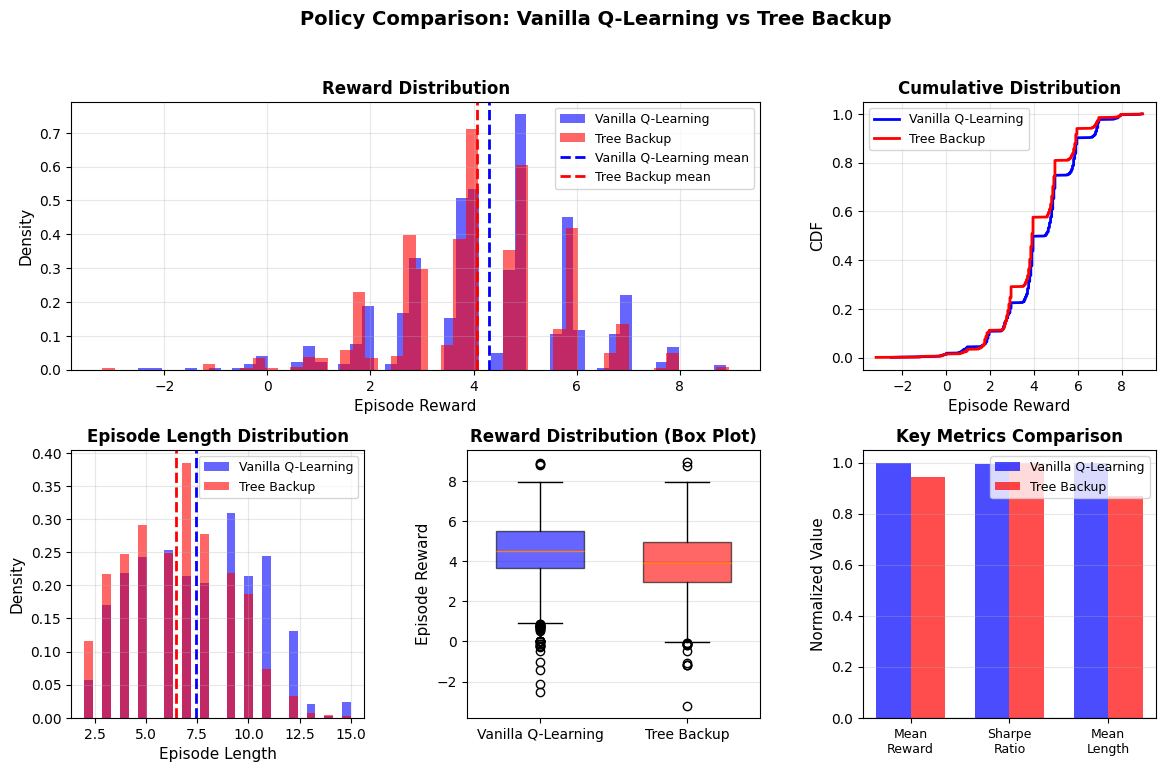

Evaluating Vanilla Q-Learning: 100%|██████████| 1000/1000 [00:00<00:00, 6386.42it/s]



Evaluation Summary: Vanilla Q-Learning
Episodes: 1000

Reward Statistics:
  Mean:          1.4093
  Std:           1.9525
  Sharpe:        0.7218
  Median:        0.4500
  Min:          -1.7500
  Max:           6.6500

Episode Length:
  Mean:           12.05
  Std:             1.28

Buy-Sell Specific Metrics:
  Completion rate:   99.60%
  Mean buy price:      0.7310
  Mean sell price:     2.7038
  Mean profit:         1.9709
  Mean holding time:    11.04



Evaluating Tree Backup: 100%|██████████| 1000/1000 [00:00<00:00, 7164.56it/s]



Evaluation Summary: Tree Backup
Episodes: 1000

Reward Statistics:
  Mean:          1.4347
  Std:           1.8935
  Sharpe:        0.7577
  Median:        0.5000
  Min:          -1.7500
  Max:           5.7000

Episode Length:
  Mean:           11.38
  Std:             1.38

Buy-Sell Specific Metrics:
  Completion rate:   99.50%
  Mean buy price:      0.7310
  Mean sell price:     2.6985
  Mean profit:         1.9678
  Mean holding time:    10.36


Policy Comparison: Vanilla Q-Learning vs Tree Backup

Metric                    Vanilla Q-Learn     Tree Backup     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        1.4093          1.4347   +0.0255 (+1.8%)   Tree Backup
Std Reward                         1.9525          1.8935   -0.0590 (-3.0%)   Tree Backup
Sharpe Ratio                       0.7218          0.7577   +0.0359 (+5.0%)   Tree Backup
Median Reward                      0.4500          0.5000   +0.0

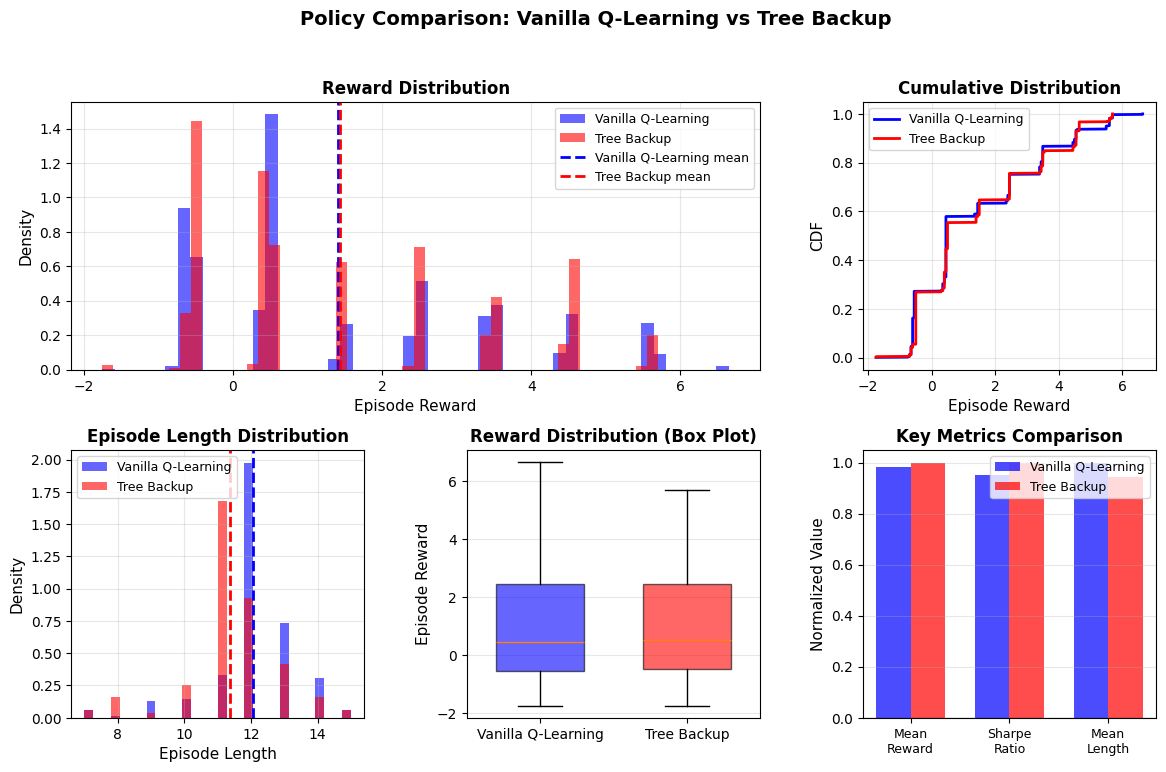

Evaluating Vanilla Q-Learning: 100%|██████████| 1000/1000 [00:00<00:00, 7608.88it/s]



Evaluation Summary: Vanilla Q-Learning
Episodes: 1000

Reward Statistics:
  Mean:          2.5895
  Std:           2.1459
  Sharpe:        1.2067
  Median:        2.4500
  Min:          -1.7500
  Max:           6.6500

Episode Length:
  Mean:           11.35
  Std:             1.56

Buy-Sell Specific Metrics:
  Completion rate:   99.80%
  Mean buy price:      0.7750
  Mean sell price:     3.8898
  Mean profit:         3.1152
  Mean holding time:    10.34



Evaluating Tree Backup: 100%|██████████| 1000/1000 [00:00<00:00, 7714.87it/s]



Evaluation Summary: Tree Backup
Episodes: 1000

Reward Statistics:
  Mean:          2.5018
  Std:           2.0693
  Sharpe:        1.2090
  Median:        2.4500
  Min:          -1.7500
  Max:           5.7000

Episode Length:
  Mean:           10.74
  Std:             1.58

Buy-Sell Specific Metrics:
  Completion rate:   99.90%
  Mean buy price:      0.7750
  Mean sell price:     3.7678
  Mean profit:         2.9930
  Mean holding time:     9.74


Policy Comparison: Vanilla Q-Learning vs Tree Backup

Metric                    Vanilla Q-Learn     Tree Backup     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        2.5895          2.5018   -0.0877 (-3.4%)   Vanilla Q-Learning
Std Reward                         2.1459          2.0693   -0.0766 (-3.6%)   Tree Backup
Sharpe Ratio                       1.2067          1.2090   +0.0023 (+0.2%)   Tree Backup
Median Reward                      2.4500          2.4500

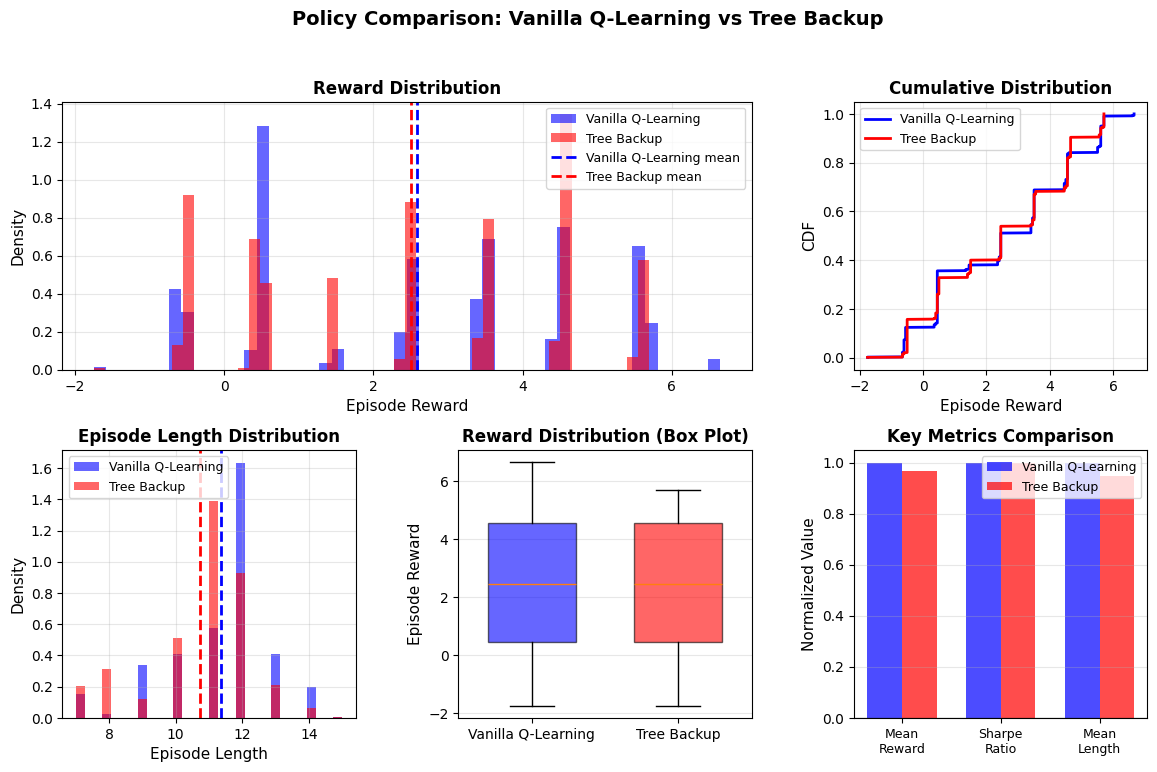

In [15]:
for env_name, env in test_envs:
    p = PolicyEvaluator(env)
    p.compare_policies(
        policy1=all_results[0]['vanilla']['agent'].get_policy(),
        policy2=all_results[0]['tree']['agent'].get_policy(),
        policy1_name='Vanilla Q-Learning',
        policy2_name='Tree Backup'
    )
    p.plot_comparison()

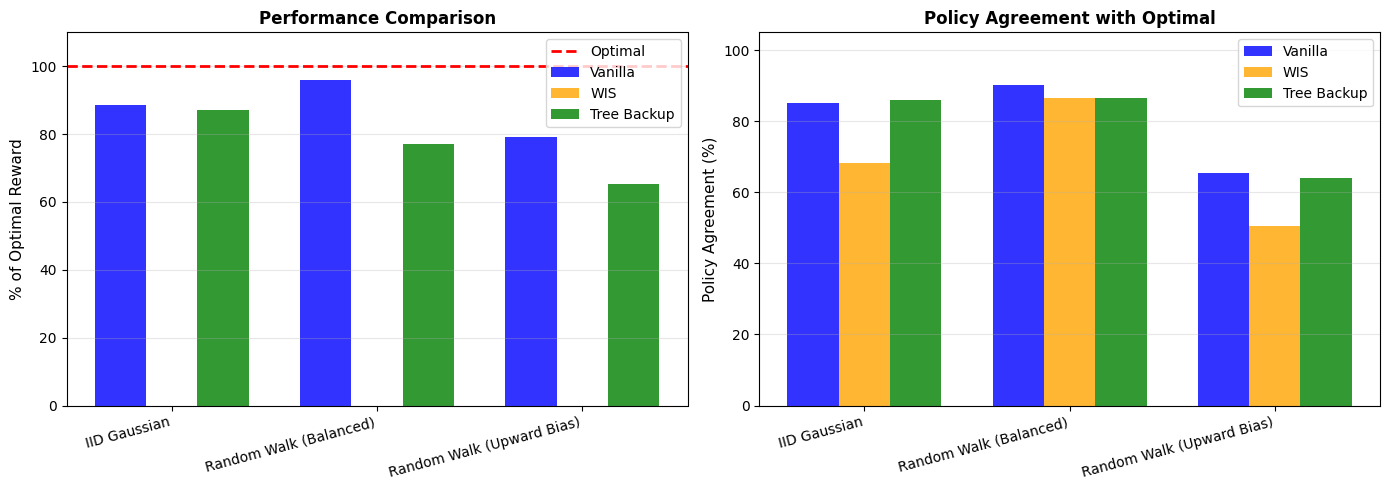

In [7]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

env_names = [r['env_name'] for r in all_results]
x = np.arange(len(env_names))
width = 0.25

# Performance comparison
vanilla_pcts = [r['vanilla']['reward'] / r['optimal']['reward'] * 100 for r in all_results]
wis_pcts = [r['wis']['reward'] / r['optimal']['reward'] * 100 for r in all_results]
tree_pcts = [r['tree']['reward'] / r['optimal']['reward'] * 100 for r in all_results]

axes[0].bar(x - width, vanilla_pcts, width, label='Vanilla', alpha=0.8, color='blue')
axes[0].bar(x, wis_pcts, width, label='WIS', alpha=0.8, color='orange')
axes[0].bar(x + width, tree_pcts, width, label='Tree Backup', alpha=0.8, color='green')
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=2, label='Optimal')
axes[0].set_ylabel('% of Optimal Reward', fontsize=11)
axes[0].set_title('Performance Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(env_names, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim(0, 110)

# Policy agreement comparison
vanilla_agree = [r['vanilla']['agreement'] * 100 for r in all_results]
wis_agree = [r['wis']['agreement'] * 100 for r in all_results]
tree_agree = [r['tree']['agreement'] * 100 for r in all_results]

axes[1].bar(x - width, vanilla_agree, width, label='Vanilla', alpha=0.8, color='blue')
axes[1].bar(x, wis_agree, width, label='WIS', alpha=0.8, color='orange')
axes[1].bar(x + width, tree_agree, width, label='Tree Backup', alpha=0.8, color='green')
axes[1].set_ylabel('Policy Agreement (%)', fontsize=11)
axes[1].set_title('Policy Agreement with Optimal', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(env_names, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

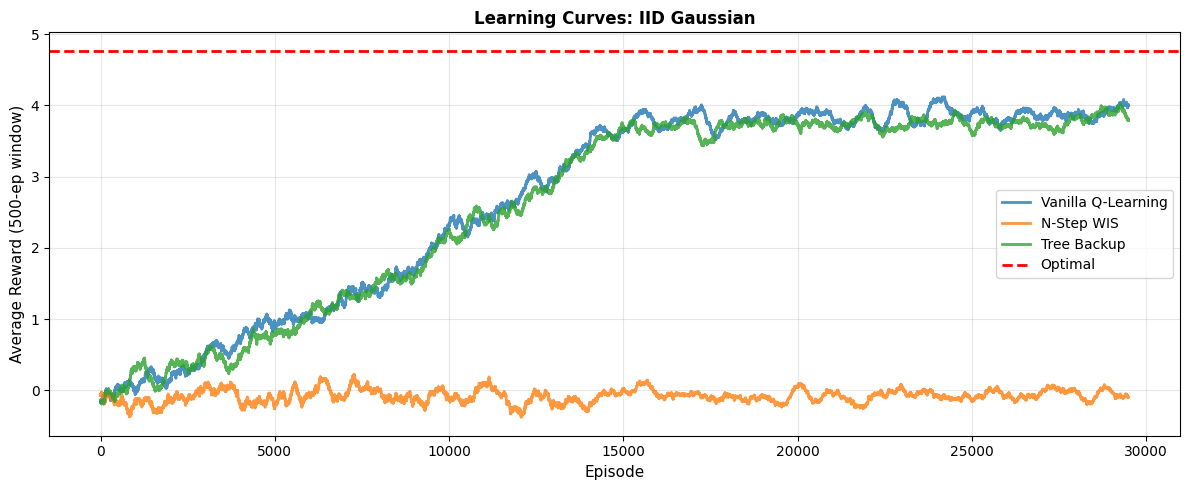

In [8]:
# Learning curves for the first environment
result = all_results[0]
fig, ax = plt.subplots(figsize=(12, 5))

window = 500
vanilla_rewards = np.convolve(result['vanilla']['agent'].episode_rewards, np.ones(window)/window, mode='valid')
wis_rewards = np.convolve(result['wis']['agent'].episode_rewards, np.ones(window)/window, mode='valid')
tree_rewards = np.convolve(result['tree']['agent'].episode_rewards, np.ones(window)/window, mode='valid')

ax.plot(vanilla_rewards, label='Vanilla Q-Learning', alpha=0.8, linewidth=2)
ax.plot(wis_rewards, label='N-Step WIS', alpha=0.8, linewidth=2)
ax.plot(tree_rewards, label='Tree Backup', alpha=0.8, linewidth=2)
ax.axhline(y=result['optimal']['reward'], color='red', linestyle='--', linewidth=2, label='Optimal')

ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel(f'Average Reward ({window}-ep window)', fontsize=11)
ax.set_title(f'Learning Curves: {result["env_name"]}', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Double Q-Learning vs Vanilla Q-Learning

In [3]:
from algorithms.q_learning import DoubleQLearningAgent

In [7]:
def compare_double_q_learning(env, env_name, n_episodes=30000, eval_episodes=2000, seed=42):
    """
    Compare Vanilla Q-Learning and Double Q-Learning.
    
    Args:
        env: Environment to test on
        env_name: Name of the environment
        n_episodes: Number of training episodes
        eval_episodes: Number of evaluation episodes
        seed: Random seed
    
    Returns:
        Dictionary with comparison results
    """
    print(f"\n{'='*80}")
    print(f"Testing on: {env_name}")
    print(f"{'='*80}")
    
    # Common hyperparameters
    alpha_sched = linear_decay_schedule(0.3, 0.01, n_episodes // 2)
    epsilon_sched = linear_decay_schedule(0.5, 0.01, n_episodes // 2)
    
    # Compute optimal policy for comparison
    print("Computing optimal policy...")
    optimal_value, optimal_policy = env.solve_optimal_policy(verbose=False)
    evaluator = PolicyEvaluator(env)
    optimal_reward = evaluator.evaluate_policy(optimal_policy, n_episodes=eval_episodes, verbose=False)['mean_reward']
    print(f"Optimal policy reward: {optimal_reward:.4f}")
    
    # Train Vanilla Q-Learning
    print("\nTraining Vanilla Q-Learning...")
    agent_vanilla = QLearningAgent(
        env=env,
        alpha=0.3,
        gamma=0.99,
        epsilon=0.5,
        alpha_schedule=alpha_sched,
        epsilon_schedule=epsilon_sched,
        seed=seed
    )
    agent_vanilla.train(env, n_episodes=n_episodes, verbose=0, use_tqdm=True)
    vanilla_policy = agent_vanilla.get_policy()
    vanilla_reward = evaluator.evaluate_policy(vanilla_policy, n_episodes=eval_episodes, verbose=False)['mean_reward']
    vanilla_agreement = np.mean(vanilla_policy == optimal_policy)
    print(f"Vanilla Q-Learning reward: {vanilla_reward:.4f} ({vanilla_reward/optimal_reward*100:.2f}% of optimal)")
    print(f"Policy agreement with optimal: {vanilla_agreement*100:.2f}%")
    
    # Train Double Q-Learning
    print("\nTraining Double Q-Learning...")
    agent_double = DoubleQLearningAgent(
        env=env,
        alpha=0.3,
        gamma=0.99,
        epsilon=0.5,
        alpha_schedule=alpha_sched,
        epsilon_schedule=epsilon_sched,
        seed=seed
    )
    agent_double.train(env, n_episodes=n_episodes, verbose=0, use_tqdm=True)
    double_policy = agent_double.get_policy()
    double_reward = evaluator.evaluate_policy(double_policy, n_episodes=eval_episodes, verbose=False)['mean_reward']
    double_agreement = np.mean(double_policy == optimal_policy)
    print(f"Double Q-Learning reward: {double_reward:.4f} ({double_reward/optimal_reward*100:.2f}% of optimal)")
    print(f"Policy agreement with optimal: {double_agreement*100:.2f}%")
    
    # Get overestimation statistics from Double Q-Learning
    ovr_stats = agent_double.get_overestimation_stats()
    print(f"\nDouble Q-Learning Q-table differences:")
    print(f"  Mean |Q1 - Q2|: {ovr_stats['mean_diff']:.4f}")
    print(f"  Max |Q1 - Q2|: {ovr_stats['max_diff']:.4f}")
    print(f"  Std |Q1 - Q2|: {ovr_stats['std_diff']:.4f}")
    print(f"  Q1 mean: {ovr_stats['q1_mean']:.4f}")
    print(f"  Q2 mean: {ovr_stats['q2_mean']:.4f}")
    
    return {
        'env_name': env_name,
        'optimal': {'reward': optimal_reward, 'policy': optimal_policy},
        'vanilla': {
            'agent': agent_vanilla,
            'policy': vanilla_policy,
            'reward': vanilla_reward,
            'agreement': vanilla_agreement
        },
        'double': {
            'agent': agent_double,
            'policy': double_policy,
            'reward': double_reward,
            'agreement': double_agreement,
            'overestimation_stats': ovr_stats
        }
    }

In [8]:
# Define test environments where overestimation bias is problematic
# Use higher variance and more complex dynamics
double_q_test_envs = [
    # High variance IID case
    ('IID High Variance', BuySellEnv(
        n_states=15, max_time=20, holding_cost_per_step=0.05,
        transition_model='iid_gaussian', transition_params={'mean': 7.5, 'std': 4.0}, seed=42
    )),
    # High variance uniform distribution
    ('IID Uniform (Wide)', BuySellEnv(
        n_states=15, max_time=20, holding_cost_per_step=0.05,
        transition_model='iid', seed=42
    )),
    # Markovian with strong upward bias (can lead to overestimation)
    ('Random Walk (Strong Upward)', BuySellEnv(
        n_states=15, max_time=20, holding_cost_per_step=0.05,
        transition_model='random_walk', transition_params={'p_up': 0.7, 'p_down': 0.3}, seed=42
    )),
    # Geometric distribution (high variance for small p)
    ('IID Geometric', BuySellEnv(
        n_states=15, max_time=20, holding_cost_per_step=0.05,
        transition_model='iid_geometric', transition_params={'p': 0.2}, seed=42
    )),
]

# Run comparisons
double_q_results = []
for env_name, env in double_q_test_envs:
    result = compare_double_q_learning(env, env_name, n_episodes=30000, eval_episodes=2000)
    double_q_results.append(result)


Testing on: IID High Variance
Computing optimal policy...
Optimal policy reward: 9.4081

Training Vanilla Q-Learning...
Optimal policy reward: 9.4081

Training Vanilla Q-Learning...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Vanilla Q-Learning reward: 7.0659 (75.10% of optimal)
Policy agreement with optimal: 75.87%

Training Double Q-Learning...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Double Q-Learning reward: 6.1476 (65.34% of optimal)
Policy agreement with optimal: 73.12%

Double Q-Learning Q-table differences:
  Mean |Q1 - Q2|: 0.1651
  Max |Q1 - Q2|: 6.7271
  Std |Q1 - Q2|: 0.5335
  Q1 mean: 1.8651
  Q2 mean: 1.8703

Testing on: IID Uniform (Wide)
Computing optimal policy...
Optimal policy reward: 11.5472

Training Vanilla Q-Learning...
Optimal policy reward: 11.5472

Training Vanilla Q-Learning...


...

Double Q-Learning reward: 3.0116 (43.08% of optimal)
Policy agreement with optimal: 51.43%

Double Q-Learning Q-table differences:
  Mean |Q1 - Q2|: 0.0224
  Max |Q1 - Q2|: 2.6580
  Std |Q1 - Q2|: 0.1604
  Q1 mean: 1.2651
  Q2 mean: 1.2623

Testing on: IID Geometric
Computing optimal policy...
Optimal policy reward: 9.0866

Training Vanilla Q-Learning...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Vanilla Q-Learning reward: 7.5251 (82.82% of optimal)
Policy agreement with optimal: 84.55%

Training Double Q-Learning...


Training:   0%|                                                      | 0/30000 [00:00<?, ?episode/s]

Double Q-Learning reward: 7.1587 (78.78% of optimal)
Policy agreement with optimal: 82.96%

Double Q-Learning Q-table differences:
  Mean |Q1 - Q2|: 0.1317
  Max |Q1 - Q2|: 4.4795
  Std |Q1 - Q2|: 0.4277
  Q1 mean: 1.6741
  Q2 mean: 1.6668


In [9]:
# Print summary table
print("\n" + "="*100)
print("COMPARISON SUMMARY: Vanilla Q-Learning vs Double Q-Learning")
print("="*100)
print(f"{'Environment':<30} {'Vanilla %Opt':<15} {'Double %Opt':<15} {'Improvement':<15} {'Winner'}")
print("-"*100)

for r in double_q_results:
    opt_reward = r['optimal']['reward']
    v_pct = r['vanilla']['reward'] / opt_reward * 100 if opt_reward != 0 else 0
    d_pct = r['double']['reward'] / opt_reward * 100 if opt_reward != 0 else 0
    improvement = d_pct - v_pct
    
    winner = 'Double Q' if d_pct > v_pct else ('Vanilla' if v_pct > d_pct else 'Tie')
    print(f"{r['env_name']:<30} {v_pct:<15.2f} {d_pct:<15.2f} {improvement:+14.2f}% {winner}")

print("="*100)

# Policy agreement summary
print("\nPOLICY AGREEMENT WITH OPTIMAL:")
print("-"*100)
print(f"{'Environment':<30} {'Vanilla':<15} {'Double Q-Learning':<15} {'Difference'}")
print("-"*100)
for r in double_q_results:
    v_agree = r['vanilla']['agreement'] * 100
    d_agree = r['double']['agreement'] * 100
    diff = d_agree - v_agree
    print(f"{r['env_name']:<30} {v_agree:<15.2f}% {d_agree:<15.2f}% {diff:+14.2f}%")
print("="*100)

# Overestimation statistics
print("\nOVERESTIMATION STATISTICS (Double Q-Learning Q-table differences):")
print("-"*100)
print(f"{'Environment':<30} {'Mean |Q1-Q2|':<15} {'Max |Q1-Q2|':<15} {'Std |Q1-Q2|'}")
print("-"*100)
for r in double_q_results:
    stats = r['double']['overestimation_stats']
    print(f"{r['env_name']:<30} {stats['mean_diff']:<15.4f} {stats['max_diff']:<15.4f} {stats['std_diff']:<15.4f}")
print("="*100)


COMPARISON SUMMARY: Vanilla Q-Learning vs Double Q-Learning
Environment                    Vanilla %Opt    Double %Opt     Improvement     Winner
----------------------------------------------------------------------------------------------------
IID High Variance              75.10           65.34                    -9.76% Vanilla
IID Uniform (Wide)             80.65           73.49                    -7.16% Vanilla
Random Walk (Strong Upward)    56.58           43.08                   -13.50% Vanilla
IID Geometric                  82.82           78.78                    -4.03% Vanilla

POLICY AGREEMENT WITH OPTIMAL:
----------------------------------------------------------------------------------------------------
Environment                    Vanilla         Double Q-Learning Difference
----------------------------------------------------------------------------------------------------
IID High Variance              75.87          % 73.12          %          -2.75%
IID Uniform (

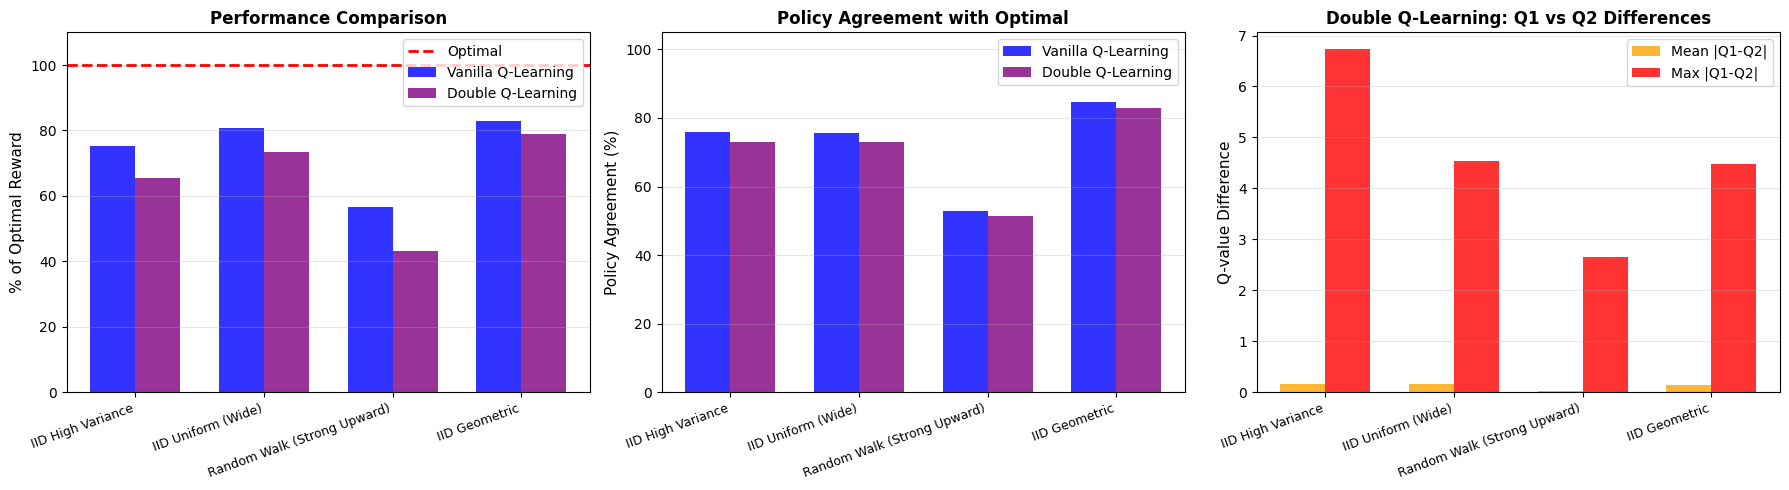

In [10]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

env_names = [r['env_name'] for r in double_q_results]
x = np.arange(len(env_names))
width = 0.35

# Performance comparison
vanilla_pcts = [r['vanilla']['reward'] / r['optimal']['reward'] * 100 for r in double_q_results]
double_pcts = [r['double']['reward'] / r['optimal']['reward'] * 100 for r in double_q_results]

axes[0].bar(x - width/2, vanilla_pcts, width, label='Vanilla Q-Learning', alpha=0.8, color='blue')
axes[0].bar(x + width/2, double_pcts, width, label='Double Q-Learning', alpha=0.8, color='purple')
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=2, label='Optimal')
axes[0].set_ylabel('% of Optimal Reward', fontsize=11)
axes[0].set_title('Performance Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(env_names, rotation=20, ha='right', fontsize=9)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim(0, 110)

# Policy agreement comparison
vanilla_agree = [r['vanilla']['agreement'] * 100 for r in double_q_results]
double_agree = [r['double']['agreement'] * 100 for r in double_q_results]

axes[1].bar(x - width/2, vanilla_agree, width, label='Vanilla Q-Learning', alpha=0.8, color='blue')
axes[1].bar(x + width/2, double_agree, width, label='Double Q-Learning', alpha=0.8, color='purple')
axes[1].set_ylabel('Policy Agreement (%)', fontsize=11)
axes[1].set_title('Policy Agreement with Optimal', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(env_names, rotation=20, ha='right', fontsize=9)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim(0, 105)

# Q-table difference statistics (Double Q only)
mean_diffs = [r['double']['overestimation_stats']['mean_diff'] for r in double_q_results]
max_diffs = [r['double']['overestimation_stats']['max_diff'] for r in double_q_results]

axes[2].bar(x - width/2, mean_diffs, width, label='Mean |Q1-Q2|', alpha=0.8, color='orange')
axes[2].bar(x + width/2, max_diffs, width, label='Max |Q1-Q2|', alpha=0.8, color='red')
axes[2].set_ylabel('Q-value Difference', fontsize=11)
axes[2].set_title('Double Q-Learning: Q1 vs Q2 Differences', fontsize=12, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(env_names, rotation=20, ha='right', fontsize=9)
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

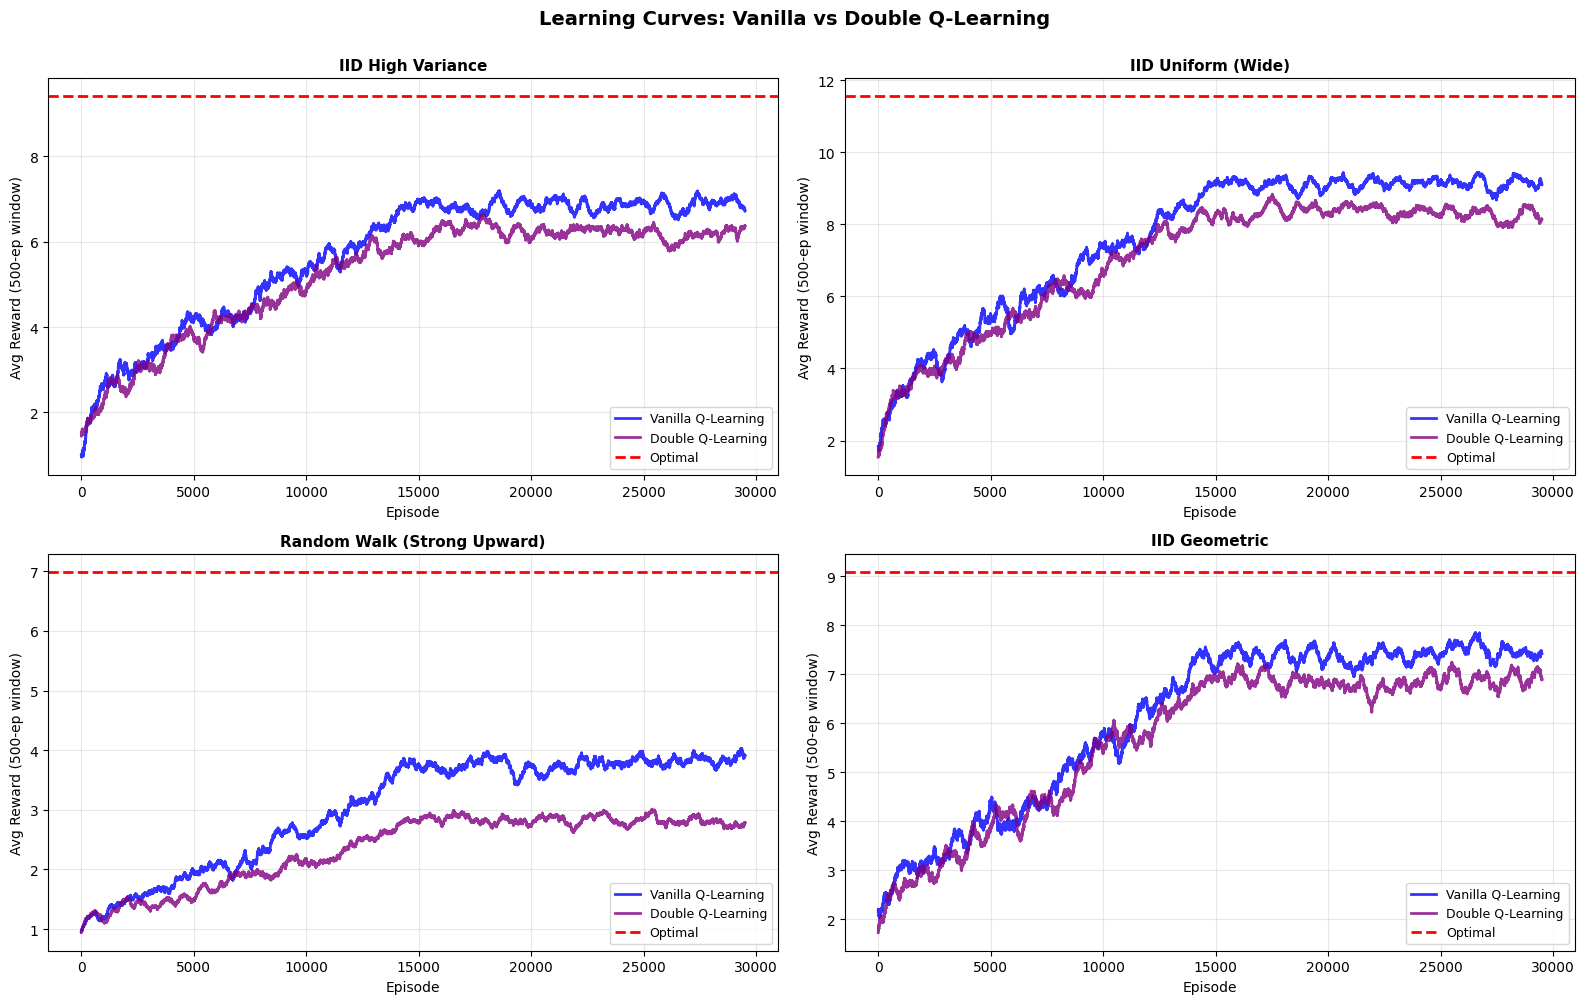

In [11]:
# Learning curves for each environment
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

window = 500

for idx, result in enumerate(double_q_results):
    ax = axes[idx]
    
    vanilla_rewards = np.convolve(result['vanilla']['agent'].episode_rewards, np.ones(window)/window, mode='valid')
    double_rewards = np.convolve(result['double']['agent'].episode_rewards, np.ones(window)/window, mode='valid')
    
    ax.plot(vanilla_rewards, label='Vanilla Q-Learning', alpha=0.8, linewidth=2, color='blue')
    ax.plot(double_rewards, label='Double Q-Learning', alpha=0.8, linewidth=2, color='purple')
    ax.axhline(y=result['optimal']['reward'], color='red', linestyle='--', linewidth=2, label='Optimal')
    
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel(f'Avg Reward ({window}-ep window)', fontsize=10)
    ax.set_title(f'{result["env_name"]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Learning Curves: Vanilla vs Double Q-Learning', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

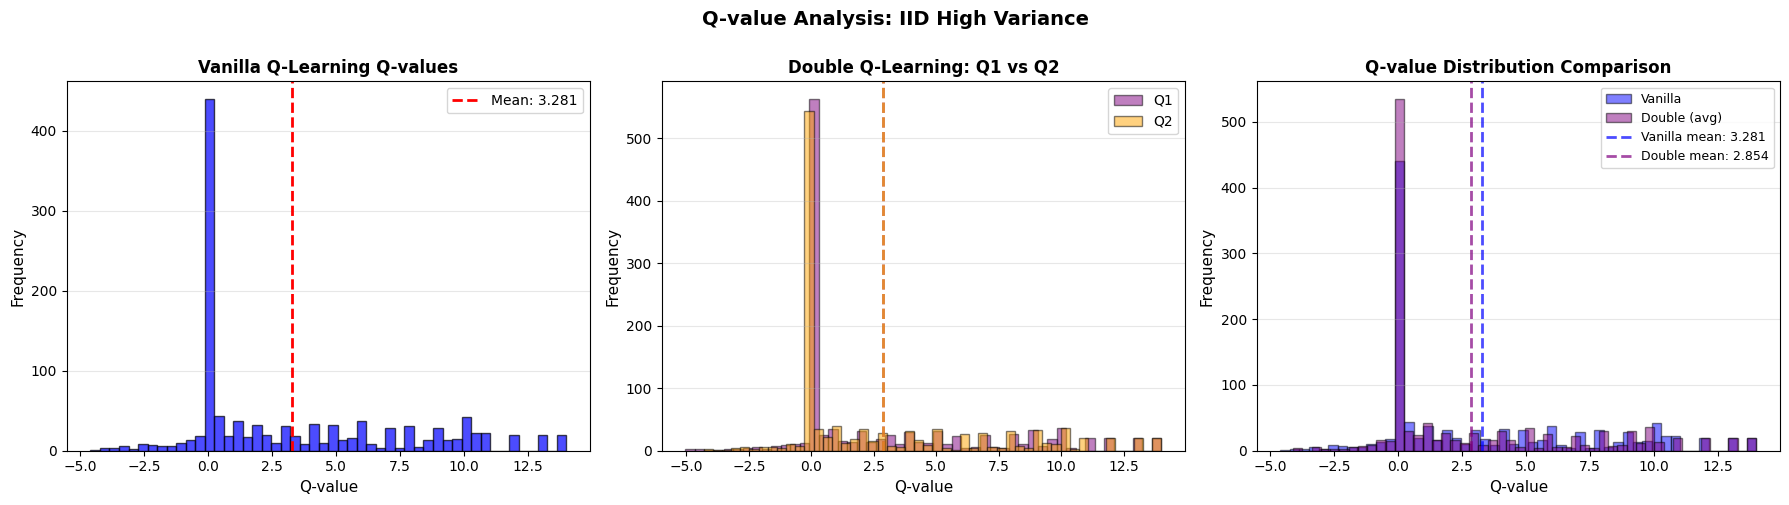


Q-value Statistics for IID High Variance:
Vanilla Q - Mean: 3.2807, Std: 4.2892
Double Q1 - Mean: 2.8501, Std: 4.1457
Double Q2 - Mean: 2.8583, Std: 4.1449
Double Q (avg) - Mean: 2.8542, Std: 4.1305

Mean difference (Vanilla - Double avg): 0.4266
→ Vanilla Q-Learning shows OVERESTIMATION compared to Double Q-Learning


In [12]:
# Compare Q-value distributions for the first environment
result = double_q_results[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get Q-tables
vanilla_q = result['vanilla']['agent'].Q
double_q1, double_q2 = result['double']['agent'].get_q_tables()
double_q_avg = (double_q1 + double_q2) / 2.0

# Flatten Q-values for histogram (excluding terminal states)
vanilla_q_flat = vanilla_q[:, 1:, 1:, :].flatten()
double_q1_flat = double_q1[:, 1:, 1:, :].flatten()
double_q2_flat = double_q2[:, 1:, 1:, :].flatten()
double_q_avg_flat = double_q_avg[:, 1:, 1:, :].flatten()

# Plot Q-value distributions
axes[0].hist(vanilla_q_flat, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Q-value', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Vanilla Q-Learning Q-values', fontsize=12, fontweight='bold')
axes[0].axvline(x=vanilla_q_flat.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {vanilla_q_flat.mean():.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Plot Double Q1 and Q2 distributions
axes[1].hist(double_q1_flat, bins=50, alpha=0.5, color='purple', edgecolor='black', label='Q1')
axes[1].hist(double_q2_flat, bins=50, alpha=0.5, color='orange', edgecolor='black', label='Q2')
axes[1].set_xlabel('Q-value', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Double Q-Learning: Q1 vs Q2', fontsize=12, fontweight='bold')
axes[1].axvline(x=double_q1_flat.mean(), color='purple', linestyle='--', linewidth=2, alpha=0.7)
axes[1].axvline(x=double_q2_flat.mean(), color='orange', linestyle='--', linewidth=2, alpha=0.7)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# Compare Vanilla vs Double (average)
axes[2].hist(vanilla_q_flat, bins=50, alpha=0.5, color='blue', edgecolor='black', label='Vanilla')
axes[2].hist(double_q_avg_flat, bins=50, alpha=0.5, color='purple', edgecolor='black', label='Double (avg)')
axes[2].set_xlabel('Q-value', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Q-value Distribution Comparison', fontsize=12, fontweight='bold')
axes[2].axvline(x=vanilla_q_flat.mean(), color='blue', linestyle='--', linewidth=2, alpha=0.7, label=f'Vanilla mean: {vanilla_q_flat.mean():.3f}')
axes[2].axvline(x=double_q_avg_flat.mean(), color='purple', linestyle='--', linewidth=2, alpha=0.7, label=f'Double mean: {double_q_avg_flat.mean():.3f}')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle(f'Q-value Analysis: {result["env_name"]}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\nQ-value Statistics for {result['env_name']}:")
print(f"Vanilla Q - Mean: {vanilla_q_flat.mean():.4f}, Std: {vanilla_q_flat.std():.4f}")
print(f"Double Q1 - Mean: {double_q1_flat.mean():.4f}, Std: {double_q1_flat.std():.4f}")
print(f"Double Q2 - Mean: {double_q2_flat.mean():.4f}, Std: {double_q2_flat.std():.4f}")
print(f"Double Q (avg) - Mean: {double_q_avg_flat.mean():.4f}, Std: {double_q_avg_flat.std():.4f}")
print(f"\nMean difference (Vanilla - Double avg): {vanilla_q_flat.mean() - double_q_avg_flat.mean():.4f}")
if vanilla_q_flat.mean() > double_q_avg_flat.mean():
    print("→ Vanilla Q-Learning shows OVERESTIMATION compared to Double Q-Learning")
else:
    print("→ No clear overestimation detected")

### DQN vs Vanilla Q-Learning on Complex Environments

In [3]:
from algorithms.dqn import DQNAgent, linear_decay_schedule as dqn_linear_decay

In [4]:
def evaluate_dqn_agent(agent, env, n_episodes=1000, verbose=False):
    """
    Evaluate a DQN agent on the environment.
    Since DQN doesn't have get_policy(), we directly evaluate it.
    
    Args:
        agent: DQN agent
        env: Environment
        n_episodes: Number of evaluation episodes
        verbose: Whether to show progress
    
    Returns:
        Dictionary with evaluation metrics
    """
    episode_rewards = []
    episode_lengths = []
    
    iterator = tqdm(range(n_episodes), desc="Evaluating DQN") if verbose else range(n_episodes)
    
    for _ in iterator:
        obs, _ = env.reset()
        state = agent._flatten_observation(obs)
        episode_reward = 0
        episode_length = 0
        done = False
        
        while not done:
            # Use greedy policy (epsilon=0)
            action = agent.select_action(state, episode=999999)  # High episode for zero epsilon
            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state = agent._flatten_observation(next_obs)
            done = terminated or truncated
            
            episode_reward += reward
            episode_length += 1
            state = next_state
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
    
    return {
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'median_reward': np.median(episode_rewards),
        'min_reward': np.min(episode_rewards),
        'max_reward': np.max(episode_rewards),
        'mean_episode_length': np.mean(episode_lengths),
        'episode_rewards': episode_rewards
    }

In [5]:
def compare_dqn_vs_qlearning(env, env_name, n_episodes=50000, eval_episodes=1000, seed=42):
    """
    Compare DQN and Vanilla Q-Learning on a complex environment.
    
    Args:
        env: Environment to test on
        env_name: Name of the environment
        n_episodes: Number of training episodes
        eval_episodes: Number of evaluation episodes
        seed: Random seed
    
    Returns:
        Dictionary with comparison results
    """
    print(f"\n{'='*80}")
    print(f"Comparing DQN vs Vanilla Q-Learning on: {env_name}")
    print(f"{'='*80}")
    
    # Compute optimal policy for comparison
    print("Computing optimal policy...")
    optimal_value, optimal_policy = env.solve_optimal_policy(verbose=False)
    evaluator = PolicyEvaluator(env)
    optimal_reward = evaluator.evaluate_policy(optimal_policy, n_episodes=eval_episodes, verbose=False)['mean_reward']
    print(f"Optimal policy reward: {optimal_reward:.4f}")
    
    # Train Vanilla Q-Learning
    print(f"\nTraining Vanilla Q-Learning ({n_episodes} episodes)...")
    alpha_sched = linear_decay_schedule(0.3, 0.01, n_episodes // 2)
    epsilon_sched = linear_decay_schedule(0.5, 0.01, n_episodes // 2)
    
    agent_vanilla = QLearningAgent(
        env=env,
        alpha=0.3,
        gamma=0.99,
        epsilon=0.5,
        alpha_schedule=alpha_sched,
        epsilon_schedule=epsilon_sched,
        seed=seed
    )
    agent_vanilla.train(env, n_episodes=n_episodes, verbose=0, use_tqdm=True)
    
    vanilla_policy = agent_vanilla.get_policy()
    vanilla_reward = evaluator.evaluate_policy(vanilla_policy, n_episodes=eval_episodes, verbose=False)['mean_reward']
    vanilla_agreement = np.mean(vanilla_policy == optimal_policy)
    
    print(f"Vanilla Q-Learning reward: {vanilla_reward:.4f} ({vanilla_reward/optimal_reward*100:.2f}% of optimal)")
    print(f"Policy agreement with optimal: {vanilla_agreement*100:.2f}%")
    
    # Train DQN
    print(f"\nTraining DQN ({n_episodes} episodes)...")
    epsilon_sched_dqn = dqn_linear_decay(1.0, 0.01, n_episodes // 2)
    
    agent_dqn = DQNAgent(
        env=env,
        hidden_dims=[256, 256, 128],
        learning_rate=5e-4,
        gamma=0.99,
        epsilon=1.0,
        epsilon_schedule=epsilon_sched_dqn,
        buffer_capacity=50000,
        batch_size=128,
        target_update_freq=100,
        seed=seed
    )
    agent_dqn.train(env, n_episodes=n_episodes, verbose=1, use_tqdm=True)
    
    # Evaluate DQN
    dqn_eval = evaluate_dqn_agent(agent_dqn, env, n_episodes=eval_episodes, verbose=False)
    dqn_reward = dqn_eval['mean_reward']
    
    print(f"DQN reward: {dqn_reward:.4f} ({dqn_reward/optimal_reward*100:.2f}% of optimal)")
    print(f"DQN std: {dqn_eval['std_reward']:.4f}")
    
    # Note: Can't compute policy agreement for DQN since it doesn't have explicit policy array
    print(f"\nNote: Policy agreement not computed for DQN (continuous function approximator)")
    
    return {
        'env_name': env_name,
        'optimal': {'reward': optimal_reward, 'policy': optimal_policy},
        'vanilla': {
            'agent': agent_vanilla,
            'policy': vanilla_policy,
            'reward': vanilla_reward,
            'agreement': vanilla_agreement,
            'std': evaluator.evaluate_policy(vanilla_policy, n_episodes=eval_episodes, verbose=False)['std_reward']
        },
        'dqn': {
            'agent': agent_dqn,
            'reward': dqn_reward,
            'std': dqn_eval['std_reward'],
            'eval_results': dqn_eval
        }
    }

In [6]:
# Define complex test environments where DQN might excel
# Use larger state spaces, longer horizons, and challenging dynamics
dqn_test_envs = [
    # Large state space with high variance
    ('Large IID High Variance', BuySellEnv(
        n_states=20, max_time=30, holding_cost_per_step=0.05,
        transition_model='iid_gaussian', transition_params={'mean': 10.0, 'std': 5.0}, seed=42
    )),
    # # Long horizon with Markovian dynamics
    # ('Long Horizon Random Walk', BuySellEnv(
    #     n_states=20, max_time=35, holding_cost_per_step=0.05,
    #     transition_model='random_walk', transition_params={'p_up': 0.6, 'p_down': 0.4}, seed=42
    # )),
    # # High variance geometric distribution
    # ('Large Geometric Distribution', BuySellEnv(
    #     n_states=18, max_time=30, holding_cost_per_step=0.05,
    #     transition_model='iid_geometric', transition_params={'p': 0.15}, seed=42
    # )),
]

# Run comparisons (warning: this will take some time!)
dqn_comparison_results = []
for env_name, env in dqn_test_envs:
    result = compare_dqn_vs_qlearning(env, env_name, n_episodes=50000, eval_episodes=1000)
    dqn_comparison_results.append(result)


Comparing DQN vs Vanilla Q-Learning on: Large IID High Variance
Computing optimal policy...
Optimal policy reward: 13.5216

Training Vanilla Q-Learning (50000 episodes)...


Training:   0%|                                                      | 0/50000 [00:00<?, ?episode/s]

Vanilla Q-Learning reward: 9.3936 (69.47% of optimal)
Policy agreement with optimal: 70.86%

Training DQN (50000 episodes)...


Training DQN:   0%|          | 0/50000 [00:00<?, ?it/s]

DQN reward: 12.9477 (95.76% of optimal)
DQN std: 3.4019

Note: Policy agreement not computed for DQN (continuous function approximator)


In [19]:
env1 = dqn_test_envs[0][1]
pe = PolicyEvaluator(env1)
pe.evaluate_policy(dqn_comparison_results[0]['vanilla']['policy'], n_episodes=2000, verbose=True)
pe.evaluate_policy(dqn_comparison_results[0]['dqn']['agent'], n_episodes=2000, verbose=True)
pe.compare_policies()
pe.plot_comparison()

Evaluating Policy: 100%|██████████| 2000/2000 [00:00<00:00, 11336.78it/s]



Evaluation Summary: Policy
Episodes: 2000

Reward Statistics:
  Mean:          9.1862
  Std:           3.6148
  Sharpe:        2.5413
  Median:        9.7000
  Min:          -8.2000
  Max:          18.8500

Episode Length:
  Mean:            6.38
  Std:             2.72

Buy-Sell Specific Metrics:
  Completion rate:   99.70%
  Mean buy price:      4.9574
  Mean sell price:    14.3250
  Mean profit:         9.3676
  Mean holding time:     3.07



Evaluating Policy:   0%|          | 0/2000 [00:00<?, ?it/s]


TypeError: 'DQNAgent' object is not subscriptable

In [7]:
# Print summary table
print("\n" + "="*100)
print("COMPARISON SUMMARY: Vanilla Q-Learning vs DQN")
print("="*100)
print(f"{'Environment':<35} {'Vanilla %Opt':<15} {'DQN %Opt':<15} {'Improvement':<15} {'Winner'}")
print("-"*100)

for r in dqn_comparison_results:
    opt_reward = r['optimal']['reward']
    v_pct = r['vanilla']['reward'] / opt_reward * 100 if opt_reward != 0 else 0
    d_pct = r['dqn']['reward'] / opt_reward * 100 if opt_reward != 0 else 0
    improvement = d_pct - v_pct
    
    winner = 'DQN' if d_pct > v_pct else ('Vanilla' if v_pct > d_pct else 'Tie')
    print(f"{r['env_name']:<35} {v_pct:<15.2f} {d_pct:<15.2f} {improvement:+14.2f}% {winner}")

print("="*100)

# Reward statistics
print("\nREWARD STATISTICS (Mean ± Std):")
print("-"*100)
print(f"{'Environment':<35} {'Vanilla':<25} {'DQN':<25} {'Optimal'}")
print("-"*100)
for r in dqn_comparison_results:
    v_str = f"{r['vanilla']['reward']:.4f} ± {r['vanilla']['std']:.4f}"
    d_str = f"{r['dqn']['reward']:.4f} ± {r['dqn']['std']:.4f}"
    o_str = f"{r['optimal']['reward']:.4f}"
    print(f"{r['env_name']:<35} {v_str:<25} {d_str:<25} {o_str}")
print("="*100)

# Policy agreement (Vanilla only)
print("\nPOLICY AGREEMENT WITH OPTIMAL (Vanilla Q-Learning only):")
print("-"*100)
print(f"{'Environment':<35} {'Vanilla Agreement':>20}")
print("-"*100)
for r in dqn_comparison_results:
    v_agree = r['vanilla']['agreement'] * 100
    print(f"{r['env_name']:<35} {v_agree:>19.2f}%")
print("="*100)


COMPARISON SUMMARY: Vanilla Q-Learning vs DQN
Environment                         Vanilla %Opt    DQN %Opt        Improvement     Winner
----------------------------------------------------------------------------------------------------
Large IID High Variance             69.47           95.76                   +26.28% DQN

REWARD STATISTICS (Mean ± Std):
----------------------------------------------------------------------------------------------------
Environment                         Vanilla                   DQN                       Optimal
----------------------------------------------------------------------------------------------------
Large IID High Variance             9.3936 ± 3.7986           12.9477 ± 3.4019          13.5216

POLICY AGREEMENT WITH OPTIMAL (Vanilla Q-Learning only):
----------------------------------------------------------------------------------------------------
Environment                            Vanilla Agreement
------------------------------

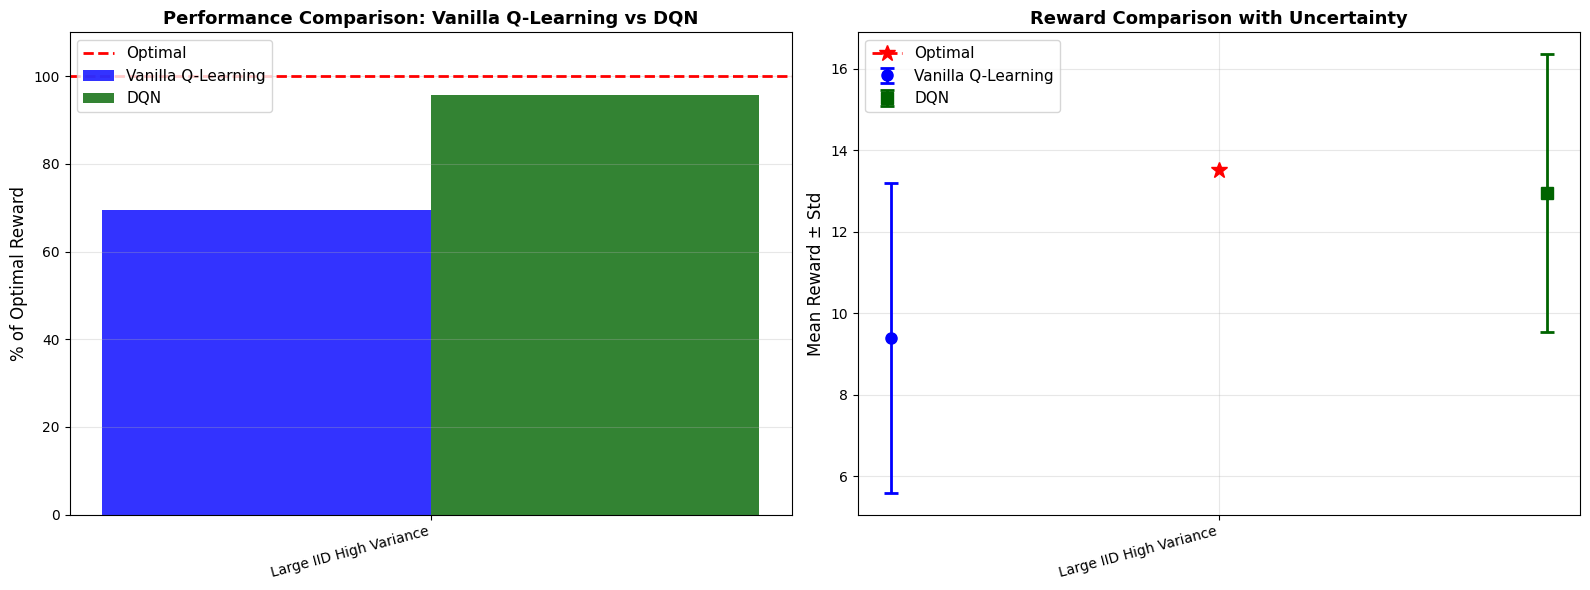

In [8]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

env_names = [r['env_name'] for r in dqn_comparison_results]
x = np.arange(len(env_names))
width = 0.35

# Performance comparison
vanilla_pcts = [r['vanilla']['reward'] / r['optimal']['reward'] * 100 for r in dqn_comparison_results]
dqn_pcts = [r['dqn']['reward'] / r['optimal']['reward'] * 100 for r in dqn_comparison_results]

axes[0].bar(x - width/2, vanilla_pcts, width, label='Vanilla Q-Learning', alpha=0.8, color='blue')
axes[0].bar(x + width/2, dqn_pcts, width, label='DQN', alpha=0.8, color='darkgreen')
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=2, label='Optimal')
axes[0].set_ylabel('% of Optimal Reward', fontsize=12)
axes[0].set_title('Performance Comparison: Vanilla Q-Learning vs DQN', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(env_names, rotation=15, ha='right', fontsize=10)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim(0, 110)

# Reward with error bars (std)
vanilla_rewards = [r['vanilla']['reward'] for r in dqn_comparison_results]
vanilla_stds = [r['vanilla']['std'] for r in dqn_comparison_results]
dqn_rewards = [r['dqn']['reward'] for r in dqn_comparison_results]
dqn_stds = [r['dqn']['std'] for r in dqn_comparison_results]
optimal_rewards = [r['optimal']['reward'] for r in dqn_comparison_results]

axes[1].errorbar(x - width/2, vanilla_rewards, yerr=vanilla_stds, fmt='o', 
                 capsize=5, capthick=2, label='Vanilla Q-Learning', color='blue', linewidth=2, markersize=8)
axes[1].errorbar(x + width/2, dqn_rewards, yerr=dqn_stds, fmt='s', 
                 capsize=5, capthick=2, label='DQN', color='darkgreen', linewidth=2, markersize=8)
axes[1].plot(x, optimal_rewards, 'r--', linewidth=2, marker='*', markersize=12, label='Optimal')
axes[1].set_ylabel('Mean Reward ± Std', fontsize=12)
axes[1].set_title('Reward Comparison with Uncertainty', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(env_names, rotation=15, ha='right', fontsize=10)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

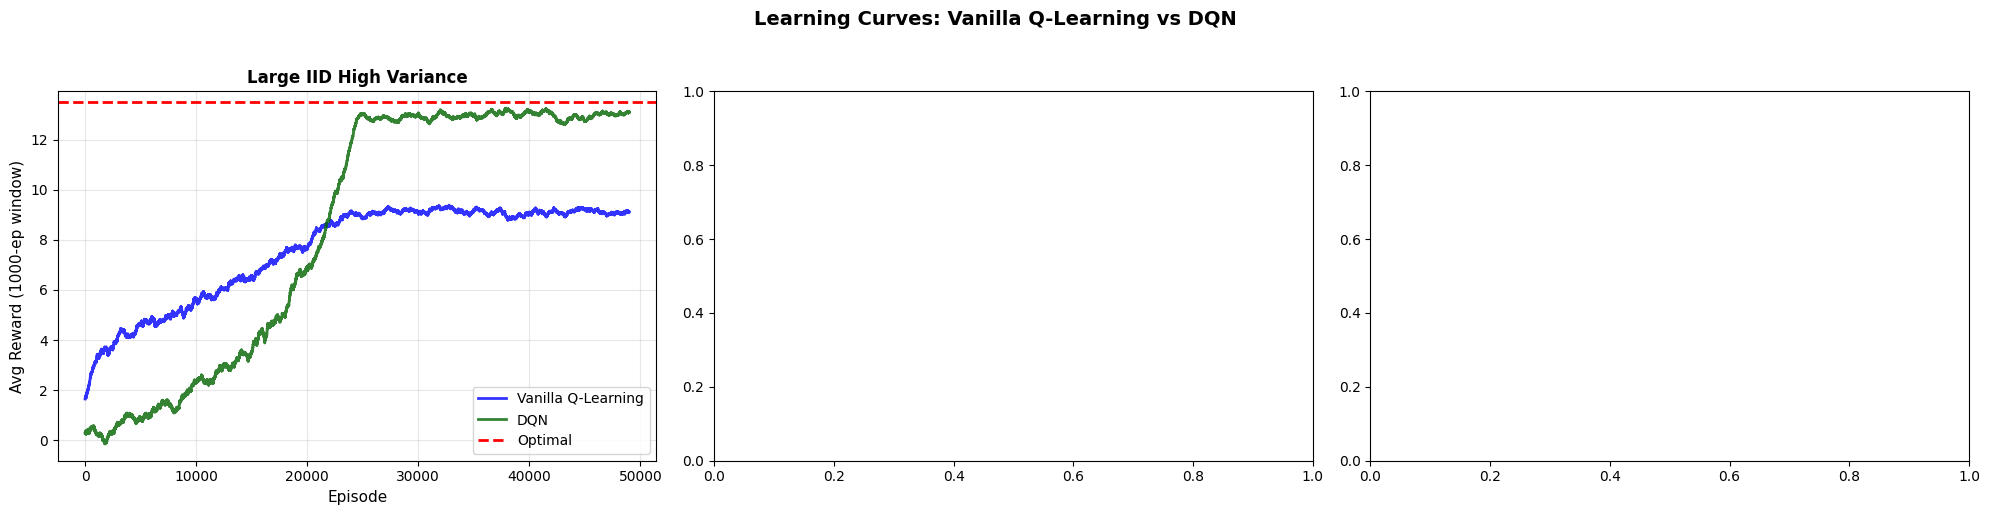

In [ ]:
# Learning curves for each environment
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Ensure 'axes' is a 1D array of Axes objects so indexing works reliably.
# plt.subplots returns either a single Axes or an ndarray of Axes.
import numpy as _np
if isinstance(axes, _np.ndarray):
    axes = axes.flatten()
else:
    axes = _np.array([axes])

window = 1000  # Larger window for DQN (more episodes)

for idx, result in enumerate(dqn_comparison_results):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    # Get episode rewards
    vanilla_rewards = result['vanilla']['agent'].episode_rewards
    dqn_rewards = result['dqn']['agent'].episode_rewards
    
    # Smooth with rolling average
    vanilla_smoothed = np.convolve(vanilla_rewards, np.ones(window)/window, mode='valid')
    dqn_smoothed = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
    
    ax.plot(vanilla_smoothed, label='Vanilla Q-Learning', alpha=0.8, linewidth=2, color='blue')
    ax.plot(dqn_smoothed, label='DQN', alpha=0.8, linewidth=2, color='darkgreen')
    ax.axhline(y=result['optimal']['reward'], color='red', linestyle='--', linewidth=2, label='Optimal')
    
    ax.set_xlabel('Episode', fontsize=11)
    ax.set_ylabel(f'Avg Reward ({window}-ep window)', fontsize=11)
    ax.set_title(f'{result["env_name"]}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.3)

plt.suptitle('Learning Curves: Vanilla Q-Learning vs DQN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

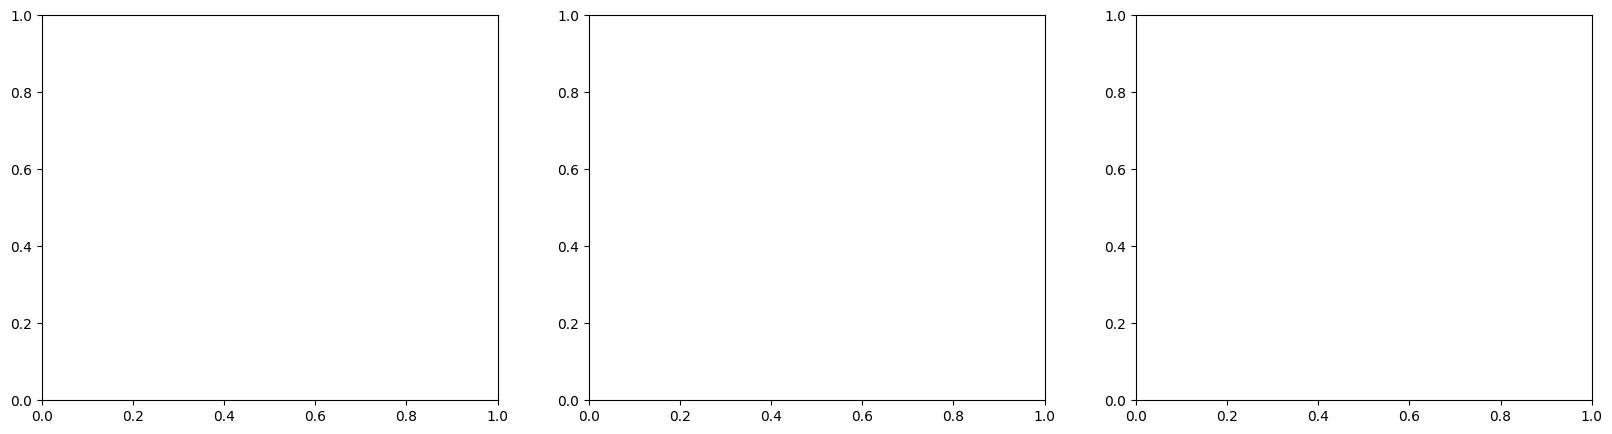

In [15]:
# DQN Training Stability: Loss curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
import numpy as _np
if isinstance(axes, _np.ndarray):
    axes = axes.flatten()
else:
    axes = _np.array([axes])
axes = axes.flatten() if len(dqn_comparison_results) > 1 else [axes]

window = 500

for idx, result in enumerate(dqn_comparison_results):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    # Get DQN losses
    losses = result['dqn']['agent'].losses
    
    if len(losses) > window:
        # Smooth with rolling average
        losses_smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
        
        ax.plot(losses_smoothed, alpha=0.8, linewidth=2, color='darkgreen')
        ax.set_xlabel('Training Step', fontsize=11)
        ax.set_ylabel(f'Loss ({window}-step avg)', fontsize=11)
        ax.set_title(f'DQN Training Loss: {result["env_name"]}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.set_yscale('log')  # Log scale often better for loss
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{result["env_name"]}', fontsize=11, fontweight='bold')

plt.suptitle('DQN Training Stability (Loss over Time)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nDQN Loss Statistics:")
for r in dqn_comparison_results:
    losses = r['dqn']['agent'].losses
    if len(losses) > 0:
        print(f"{r['env_name']}:")
        print(f"  Final 1000 steps - Mean: {np.mean(losses[-1000:]):.6f}, Std: {np.std(losses[-1000:]):.6f}")
        print(f"  Overall - Mean: {np.mean(losses):.6f}, Max: {np.max(losses):.6f}")